In [1]:
!pip install libpysal esda geopandas -q
print("Librerías instaladas")

Librerías instaladas


In [3]:
from google.colab import drive
import pandas as pd
import geopandas as gpd

drive.mount('/content/drive')
carpeta = '/content/drive/MyDrive/ACDSA_2027/'

# Cargar tabla maestra ICSHM-EO
df = pd.read_csv(carpeta + 'Atrato_ICSHM_EO_tabla_maestra.csv')
print(f"Tabla maestra: {len(df)} filas")
print(f"ICSHM_EO valido: {df['ICSHM_EO'].notna().sum()}")

# Cargar shapefile
shp_path = carpeta + 'Atrato_subcuencas_170_v2.shp'
gdf = gpd.read_file(shp_path)
print(f"\nShapefile: {len(gdf)} polígonos")
print(f"CRS: {gdf.crs}")
print(f"Columnas shapefile: {list(gdf.columns)}")
print(f"\nPrimer HYBAS_ID shapefile: {gdf['HYBAS_ID'].iloc[0]}")
print(f"Primer HYBAS_ID tabla:     {df['HYBAS_ID'].iloc[0]}")

# Unir geometria + tabla por HYBAS_ID
gdf_merged = gdf.merge(df, on='HYBAS_ID', how='left')
print(f"\nDespués del merge: {len(gdf_merged)} filas")
print(f"Con ICSHM_EO válido: {gdf_merged['ICSHM_EO'].notna().sum()}")
print(f"Sin ICSHM_EO (sin coincidencia): {gdf_merged['ICSHM_EO'].isna().sum()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Tabla maestra: 170 filas
ICSHM_EO valido: 170


DataSourceError: Unable to open /content/drive/MyDrive/ACDSA_2027/Atrato_subcuencas_170_v2.shx or /content/drive/MyDrive/ACDSA_2027/Atrato_subcuencas_170_v2.SHX. Set SHAPE_RESTORE_SHX config option to YES to restore or create it.

In [6]:
import os
os.environ['SHAPE_RESTORE_SHX'] = 'YES'

import geopandas as gpd
carpeta = '/content/drive/MyDrive/ACDSA_2027/'
gdf = gpd.read_file(carpeta + 'Atrato_subcuencas_170_v2.shp')

print(f"Shapefile cargado: {len(gdf)} polígonos")
print(f"CRS: {gdf.crs}")
print(f"Columnas: {list(gdf.columns)}")

Shapefile cargado: 144 polígonos
CRS: EPSG:4326
Columnas: ['area_total', 'geom_type', 'HYBAS_ID', 'geometry']


In [7]:
import pandas as pd

# Cargar tabla maestra ICSHM-EO
df = pd.read_csv(carpeta + 'Atrato_ICSHM_EO_tabla_maestra.csv')
print(f"Tabla maestra: {len(df)} filas")
print(f"ICSHM_EO valido: {df['ICSHM_EO'].notna().sum()}")

# Verificar tipos de HYBAS_ID
print(f"\nTipo HYBAS_ID en shapefile: {gdf['HYBAS_ID'].dtype}")
print(f"Tipo HYBAS_ID en tabla:     {df['HYBAS_ID'].dtype}")

# Forzar mismo tipo por si acaso
gdf['HYBAS_ID'] = gdf['HYBAS_ID'].astype('int64')
df['HYBAS_ID'] = df['HYBAS_ID'].astype('int64')

# Merge
gdf_merged = gdf.merge(df, on='HYBAS_ID', how='left')

print(f"\nDespues del merge: {len(gdf_merged)} filas")
print(f"Con ICSHM_EO valido: {gdf_merged['ICSHM_EO'].notna().sum()}")
print(f"Sin ICSHM_EO (subcuencas del shapefile sin dato): {gdf_merged['ICSHM_EO'].isna().sum()}")

# Filtrar solo las que tienen ICSHM_EO valido para LISA
gdf_valid = gdf_merged[gdf_merged['ICSHM_EO'].notna()].copy().reset_index(drop=True)
print(f"\nSubcuencas listas para LISA: {len(gdf_valid)}")

Tabla maestra: 170 filas
ICSHM_EO valido: 170

Tipo HYBAS_ID en shapefile: int64
Tipo HYBAS_ID en tabla:     int64

Despues del merge: 144 filas
Con ICSHM_EO valido: 144
Sin ICSHM_EO (subcuencas del shapefile sin dato): 0

Subcuencas listas para LISA: 144


In [9]:
import numpy as np
import libpysal
from esda.moran import Moran, Moran_Local
from statsmodels.stats.multitest import multipletests

# ---------- 1. MATRIZ DE PESOS ESPACIALES KNN k=8 ----------
coords = np.array([[geom.centroid.x, geom.centroid.y] for geom in gdf_valid.geometry])
w = libpysal.weights.KNN.from_array(coords, k=8)
w.transform = 'r'
print(f"Matriz de pesos KNN: {w.n} unidades, k=8, estandarizada por filas")

# ---------- 2. MORAN'S I GLOBAL ----------
print("\n" + "=" * 60)
print("MORAN'S I GLOBAL con 999 permutaciones")
print("=" * 60)

y = gdf_valid['ICSHM_EO'].values
moran = Moran(y, w, permutations=999)

print(f"Moran's I:  {moran.I:.4f}")
print(f"E[I]:       {moran.EI:.4f}")
print(f"Z-score:    {moran.z_sim:.4f}")
print(f"p-value:    {moran.p_sim:.4f}")

if moran.p_sim < 0.05:
    if moran.I > moran.EI:
        print("Interpretacion: Autocorrelacion espacial POSITIVA significativa (agrupamiento)")
    else:
        print("Interpretacion: Autocorrelacion espacial NEGATIVA (dispersion)")
else:
    print("Interpretacion: Sin autocorrelacion espacial significativa")

# ---------- 3. LOCAL MORAN (LISA) ----------
print("\n" + "=" * 60)
print("LISA: Local Moran's I con 999 permutaciones")
print("=" * 60)

lisa = Moran_Local(y, w, permutations=999)
gdf_valid['Ii'] = lisa.Is
gdf_valid['p_sim'] = lisa.p_sim
gdf_valid['quadrant'] = lisa.q

# ---------- 4. CORRECCION FDR BENJAMINI-HOCHBERG ----------
print("\n" + "=" * 60)
print("CORRECCION FDR Benjamini-Hochberg")
print("=" * 60)

reject, p_fdr, _, _ = multipletests(gdf_valid['p_sim'].values, alpha=0.05, method='fdr_bh')
gdf_valid['p_fdr'] = p_fdr
gdf_valid['significativo_FDR'] = reject

print(f"Antes de FDR: {(gdf_valid['p_sim'] < 0.05).sum()} subcuencas significativas (alpha=0.05)")
print(f"Despues FDR:  {reject.sum()} subcuencas significativas")

# ---------- 5. CATEGORIZACION LISA ----------
def categorizar(row):
    if not row['significativo_FDR']:
        return 'NS'
    q = row['quadrant']
    if q == 1: return 'High-High'
    elif q == 2: return 'Low-High'
    elif q == 3: return 'Low-Low'
    elif q == 4: return 'High-Low'
    return 'NS'

gdf_valid['LISA_cat'] = gdf_valid.apply(categorizar, axis=1)

print(f"\nDistribucion de categorias LISA (post-FDR):")
print(gdf_valid['LISA_cat'].value_counts())

# ---------- 6. GUARDAR RESULTADO ----------
gdf_valid.drop(columns='geometry').to_csv(carpeta + 'Atrato_LISA_resultados.csv', index=False)
gdf_valid.to_file(carpeta + 'Atrato_LISA_resultados.gpkg', driver='GPKG')
print(f"\n✅ Resultados LISA guardados en Drive")

Matriz de pesos KNN: 144 unidades, k=8, estandarizada por filas

MORAN'S I GLOBAL con 999 permutaciones
Moran's I:  0.1852
E[I]:       -0.0070
Z-score:    4.9444
p-value:    0.0010
Interpretacion: Autocorrelacion espacial POSITIVA significativa (agrupamiento)

LISA: Local Moran's I con 999 permutaciones

CORRECCION FDR Benjamini-Hochberg
Antes de FDR: 43 subcuencas significativas (alpha=0.05)
Despues FDR:  18 subcuencas significativas

Distribucion de categorias LISA (post-FDR):
LISA_cat
NS           126
Low-Low       14
High-High      3
High-Low       1
Name: count, dtype: int64

✅ Resultados LISA guardados en Drive


In [11]:
# ---------- SENSIBILIDAD 1: variando tau ----------
print("=" * 60)
print("SENSIBILIDAD 1: variacion del umbral de veto tau")
print("=" * 60)

for tau_test in [0.15, 0.20, 0.25]:
    def veto_test(row):
        vals = [row['D1_norm'], row['D2_norm'], row['D4_norm'], row['D5_norm']]
        vals = [v for v in vals if not pd.isna(v)]
        return any(v < tau_test for v in vals) if vals else False
    col = f'veto_tau_{tau_test}'
    df[col] = df.apply(veto_test, axis=1)
    n = df[col].sum()
    print(f"  tau = {tau_test}: {n} subcuencas con veto activado ({100*n/len(df):.1f}%)")

# ---------- SENSIBILIDAD 2: pesos iguales vs entropia ----------
print("\n" + "=" * 60)
print("SENSIBILIDAD 2: pesos iguales vs pesos por entropia")
print("=" * 60)

df['ICSHM_pesos_iguales'] = df[['D1_norm', 'D2_norm', 'D4_norm', 'D5_norm']].mean(axis=1, skipna=True)

def entropia_shannon(serie):
    s = serie.dropna()
    hist, _ = np.histogram(s, bins=10, density=True)
    hist = hist[hist > 0]
    return -np.sum(hist * np.log(hist))

pesos_entropia = {}
for dim in ['D1_norm', 'D2_norm', 'D4_norm', 'D5_norm']:
    pesos_entropia[dim] = entropia_shannon(df[dim])

suma = sum(pesos_entropia.values())
pesos_entropia = {k: v/suma for k, v in pesos_entropia.items()}
print(f"Pesos por entropia:")
for k, v in pesos_entropia.items():
    print(f"  {k}: {v:.3f}")

df['ICSHM_pesos_entropia'] = 0
for dim, w_ent in pesos_entropia.items():
    df['ICSHM_pesos_entropia'] += df[dim].fillna(df[dim].mean()) * w_ent

# ---------- ROBUSTEZ ----------
def clasif(icshm):
    if pd.isna(icshm): return 'NA'
    if icshm < 0.20: return 'Critico'
    elif icshm < 0.40: return 'Bajo'
    elif icshm < 0.60: return 'Medio'
    elif icshm < 0.80: return 'Alto'
    else: return 'Seguro'

df['cat_iguales'] = df['ICSHM_pesos_iguales'].apply(clasif)
df['cat_entropia'] = df['ICSHM_pesos_entropia'].apply(clasif)
df['robustez'] = (df['cat_iguales'] == df['cat_entropia']).astype(int)

n_robustas = df['robustez'].sum()
n_total = len(df)
print(f"\nRobustez: {n_robustas} de {n_total} subcuencas ({100*n_robustas/n_total:.1f}%) mantienen categoria")

# Guardar
df.to_csv(carpeta + 'Atrato_sensibilidad.csv', index=False)
print(f"\n✅ Sensibilidad guardada en Drive")

SENSIBILIDAD 1: variacion del umbral de veto tau
  tau = 0.15: 23 subcuencas con veto activado (13.5%)
  tau = 0.2: 40 subcuencas con veto activado (23.5%)
  tau = 0.25: 58 subcuencas con veto activado (34.1%)

SENSIBILIDAD 2: pesos iguales vs pesos por entropia
Pesos por entropia:
  D1_norm: 0.085
  D2_norm: 0.238
  D4_norm: 0.038
  D5_norm: 0.639

Robustez: 43 de 170 subcuencas (25.3%) mantienen categoria

✅ Sensibilidad guardada en Drive


In [12]:
# Analisis de confiabilidad por subcuenca
def color_confiabilidad(n):
    if n == 4: return 'Verde (4 indicadores)'
    elif n >= 2: return 'Amarillo (2-3 indicadores)'
    else: return 'Rojo (0-1 indicador)'

df['confiabilidad'] = df['n_indicadores_validos'].apply(color_confiabilidad)

print("=" * 60)
print("CONFIABILIDAD DE DATOS POR SUBCUENCA")
print("=" * 60)

print("\nDistribucion por categoria:")
print(df['confiabilidad'].value_counts())

print("\nProporcion:")
print((df['confiabilidad'].value_counts(normalize=True) * 100).round(1))

# Cruzar confiabilidad con ICSHM_EO promedio
print("\nICSHM_EO promedio por nivel de confiabilidad:")
print(df.groupby('confiabilidad')['ICSHM_EO'].describe().round(3))

# Guardar
df[['HYBAS_ID', 'n_indicadores_validos', 'confiabilidad', 'ICSHM_EO', 'categoria']].to_csv(
    carpeta + 'Atrato_confiabilidad.csv', index=False)
print(f"\n✅ Confiabilidad guardada")

CONFIABILIDAD DE DATOS POR SUBCUENCA

Distribucion por categoria:
confiabilidad
Verde (4 indicadores)         140
Amarillo (2-3 indicadores)     30
Name: count, dtype: int64

Proporcion:
confiabilidad
Verde (4 indicadores)         82.4
Amarillo (2-3 indicadores)    17.6
Name: proportion, dtype: float64

ICSHM_EO promedio por nivel de confiabilidad:
                            count   mean    std    min    25%    50%    75%  \
confiabilidad                                                                 
Amarillo (2-3 indicadores)   30.0  0.740  0.123  0.497  0.638  0.780  0.815   
Verde (4 indicadores)       140.0  0.589  0.108  0.347  0.496  0.601  0.664   

                              max  
confiabilidad                      
Amarillo (2-3 indicadores)  0.992  
Verde (4 indicadores)       0.842  

✅ Confiabilidad guardada


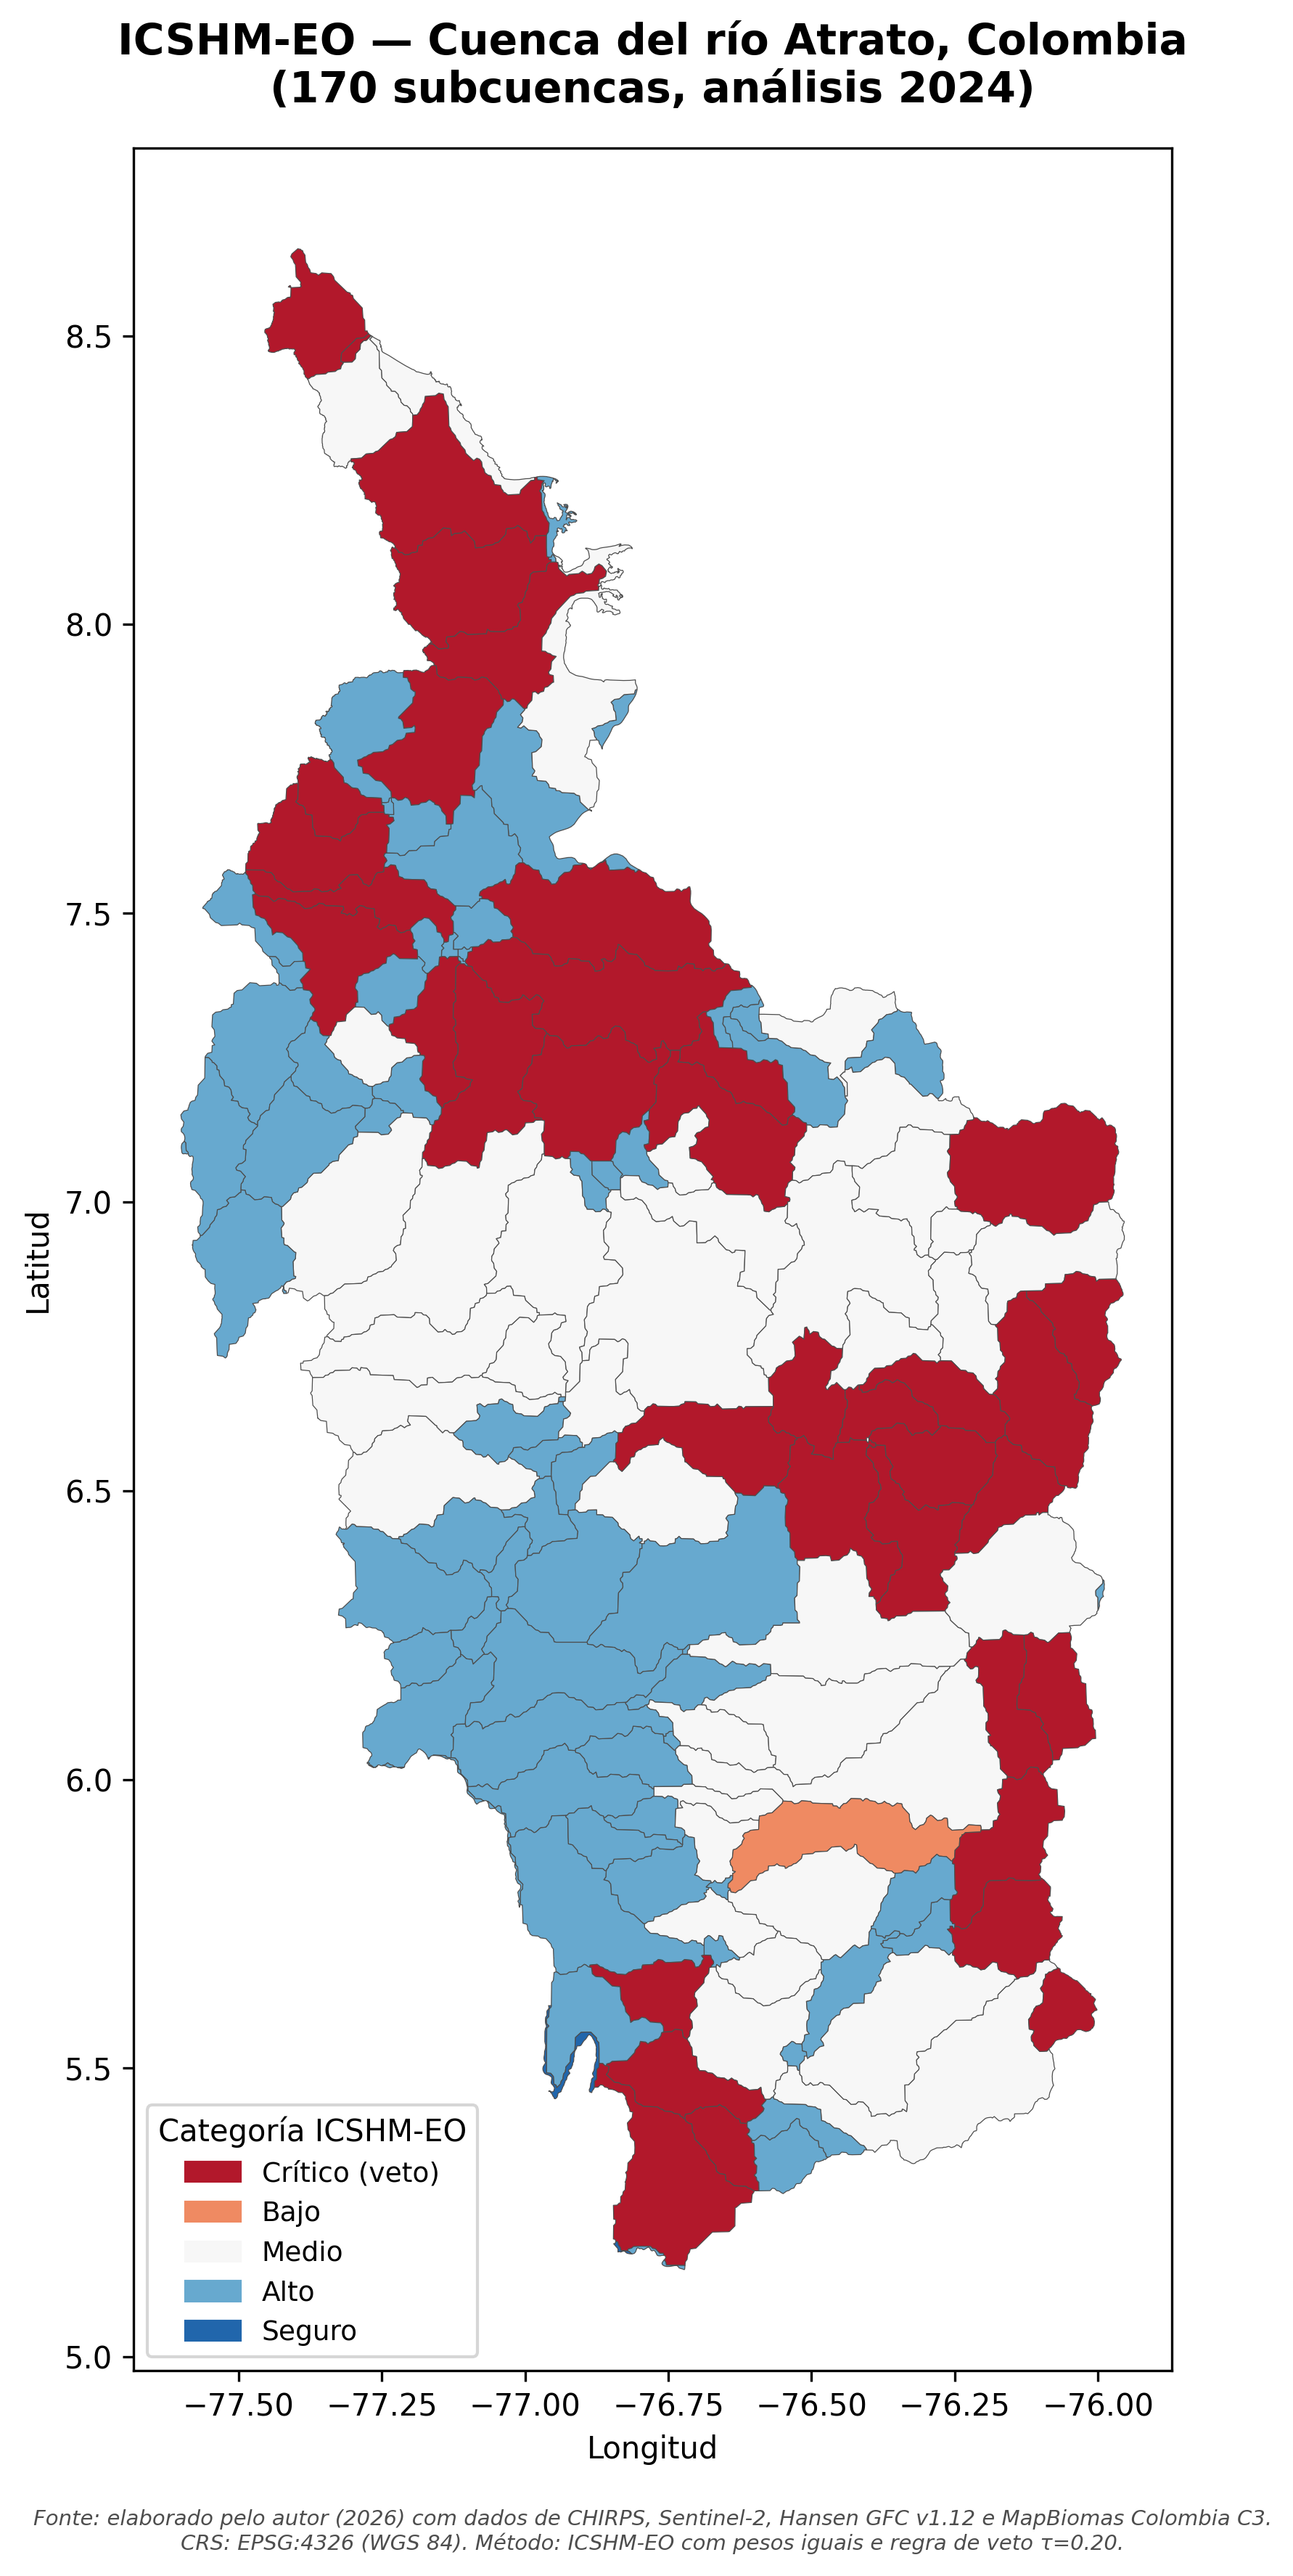


✅ Figura 3 guardada en Drive (PNG + PDF)
Subcuencas mapeadas: 144


In [13]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

# Definir paleta ICSHM ColorBrewer RdBu divergente
colores_icshm = {
    'Crítico (veto)': '#B2182B',
    'Crítico':         '#B2182B',
    'Bajo':            '#EF8A62',
    'Medio':           '#F7F7F7',
    'Alto':            '#67A9CF',
    'Seguro':          '#2166AC'
}

# Asignar color a cada subcuenca segun su categoria
gdf_valid['color'] = gdf_valid['categoria'].map(colores_icshm)

# Crear figura
fig, ax = plt.subplots(1, 1, figsize=(10, 12), dpi=300)

# Plotear subcuencas
gdf_valid.plot(
    ax=ax,
    color=gdf_valid['color'],
    edgecolor='#4D4D4D',
    linewidth=0.3
)

# Titulo y etiquetas
ax.set_title('ICSHM-EO — Cuenca del río Atrato, Colombia\n(170 subcuencas, análisis 2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Longitud', fontsize=10)
ax.set_ylabel('Latitud', fontsize=10)

# Leyenda
categorias_orden = ['Crítico (veto)', 'Bajo', 'Medio', 'Alto', 'Seguro']
patches = [mpatches.Patch(color=colores_icshm[cat], label=cat)
           for cat in categorias_orden if cat in gdf_valid['categoria'].unique()]
ax.legend(handles=patches, loc='lower left', fontsize=9,
          title='Categoría ICSHM-EO', title_fontsize=10, frameon=True)

# Nota al pie con fuente
plt.figtext(0.5, 0.02,
            'Fonte: elaborado pelo autor (2026) com dados de CHIRPS, Sentinel-2, Hansen GFC v1.12 e MapBiomas Colombia C3.\n'
            'CRS: EPSG:4326 (WGS 84). Método: ICSHM-EO com pesos iguais e regra de veto τ=0.20.',
            ha='center', fontsize=7, style='italic', color='#4D4D4D')

# Ajustar layout
plt.tight_layout(rect=[0, 0.04, 1, 1])

# Guardar en Drive
plt.savefig(carpeta + 'Fig3_ICSHM_EO_Atrato.png', dpi=300, bbox_inches='tight')
plt.savefig(carpeta + 'Fig3_ICSHM_EO_Atrato.pdf', bbox_inches='tight')
plt.show()

print("\n✅ Figura 3 guardada en Drive (PNG + PDF)")
print(f"Subcuencas mapeadas: {len(gdf_valid)}")

/tmp/ipykernel_1803/2324863068.py:86: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  patches.append(mpatches.Patch(color=colores_icshm[cat], label=label,


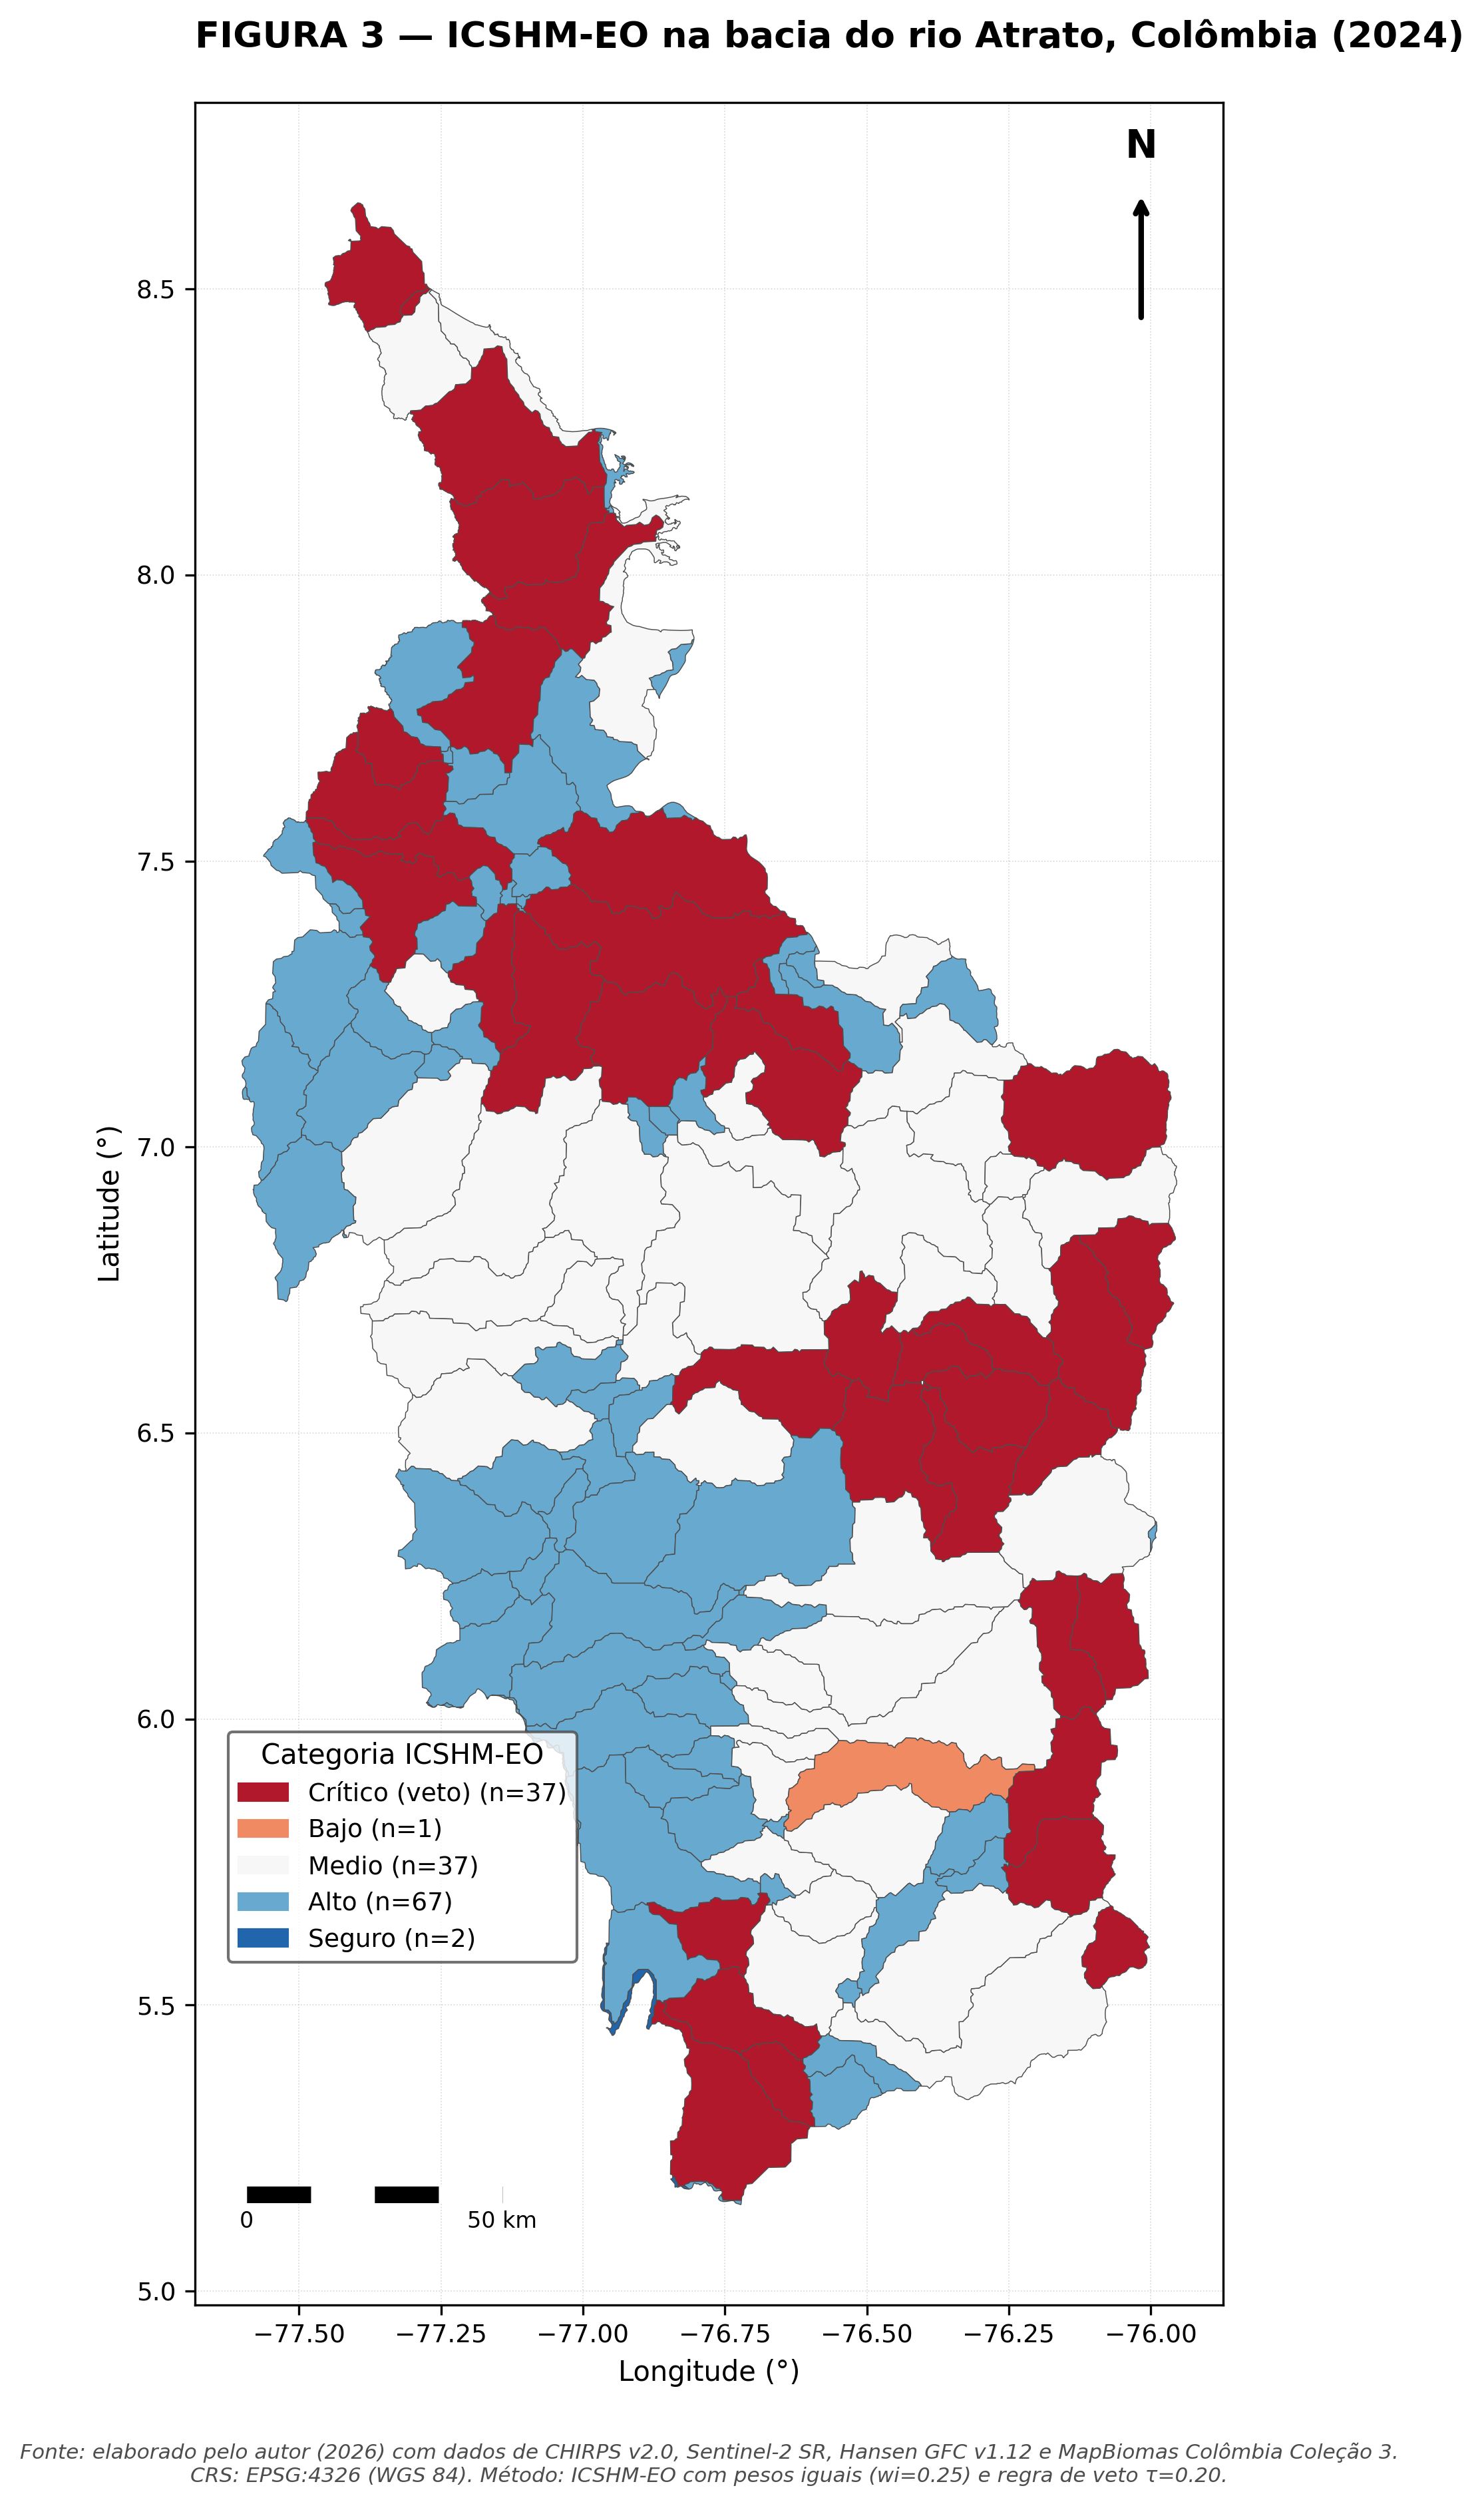


✅ Figura 3 pulida (nivel doctoral)
Subcuencas mapeadas: 144
Distribución categorías presentes: {'Alto': np.int64(67), 'Crítico (veto)': np.int64(37), 'Medio': np.int64(37), 'Seguro': np.int64(2), 'Bajo': np.int64(1)}


In [15]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D

# Paleta ICSHM ColorBrewer RdBu divergente
colores_icshm = {
    'Crítico (veto)': '#B2182B',
    'Crítico':         '#B2182B',
    'Bajo':            '#EF8A62',
    'Medio':           '#F7F7F7',
    'Alto':            '#67A9CF',
    'Seguro':          '#2166AC'
}

gdf_valid['color'] = gdf_valid['categoria'].map(colores_icshm)

# Figura con proporciones cartográficas doctorales
fig, ax = plt.subplots(1, 1, figsize=(11, 13), dpi=300)

# Plotear subcuencas
gdf_valid.plot(
    ax=ax,
    color=gdf_valid['color'],
    edgecolor='#4D4D4D',
    linewidth=0.35
)

# Titulo formato ABNT en portugués (paper IEEE final va en inglés, esto es para revisión doctoral)
ax.set_title('FIGURA 3 — ICSHM-EO na bacia do rio Atrato, Colômbia (2024)',
             fontsize=13, fontweight='bold', pad=20, loc='left')

# Ejes con formato geográfico
ax.set_xlabel('Longitude (°)', fontsize=10)
ax.set_ylabel('Latitude (°)', fontsize=10)
ax.tick_params(labelsize=9)

# ---- ESCALA GRÁFICA ----
# Escala en kilómetros basada en extensión del mapa
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

# 1° latitud ≈ 111 km, escala de 50 km
escala_km = 50
escala_grados = escala_km / 111
x_escala_start = xmin + (xmax - xmin) * 0.05
y_escala = ymin + (ymax - ymin) * 0.05

# Barra de escala con 4 segmentos alternos
segmentos = 4
for i in range(segmentos):
    color = 'black' if i % 2 == 0 else 'white'
    x0 = x_escala_start + i * (escala_grados / segmentos)
    x1 = x_escala_start + (i + 1) * (escala_grados / segmentos)
    ax.plot([x0, x1], [y_escala, y_escala], color=color, linewidth=6,
            solid_capstyle='butt', zorder=10)
    ax.plot([x0, x1], [y_escala, y_escala], color='black', linewidth=6,
            solid_capstyle='butt', fillstyle='none', zorder=9)

# Etiquetas de escala
ax.text(x_escala_start, y_escala - (ymax-ymin)*0.015, '0',
        fontsize=8, ha='center', zorder=11)
ax.text(x_escala_start + escala_grados, y_escala - (ymax-ymin)*0.015,
        f'{escala_km} km', fontsize=8, ha='center', zorder=11)

# ---- FLECHA DE NORTE ----
x_norte = xmin + (xmax - xmin) * 0.92
y_norte_base = ymin + (ymax - ymin) * 0.90
y_norte_punta = y_norte_base + (ymax - ymin) * 0.06

ax.annotate('', xy=(x_norte, y_norte_punta), xytext=(x_norte, y_norte_base),
            arrowprops=dict(arrowstyle='->', color='black', lw=2), zorder=10)
ax.text(x_norte, y_norte_punta + (ymax-ymin)*0.015, 'N',
        fontsize=14, fontweight='bold', ha='center', zorder=11)

# ---- LEYENDA solo con categorías presentes ----
categorias_presentes = gdf_valid['categoria'].value_counts()
categorias_orden = ['Crítico (veto)', 'Bajo', 'Medio', 'Alto', 'Seguro']

patches = []
for cat in categorias_orden:
    if cat in categorias_presentes.index:
        n = categorias_presentes[cat]
        label = f'{cat} (n={n})'
        patches.append(mpatches.Patch(color=colores_icshm[cat], label=label,
                                      edgecolor='#4D4D4D', linewidth=0.5))

ax.legend(handles=patches, loc='lower left',
          bbox_to_anchor=(0.02, 0.15),
          fontsize=9, title='Categoria ICSHM-EO',
          title_fontsize=10, frameon=True,
          facecolor='white', edgecolor='#4D4D4D')

# Grid sutil
ax.grid(True, linestyle=':', linewidth=0.4, color='#B0B0B0', alpha=0.5)
ax.set_axisbelow(True)

# Fonte formato ABNT
plt.figtext(0.5, 0.02,
            'Fonte: elaborado pelo autor (2026) com dados de CHIRPS v2.0, Sentinel-2 SR, Hansen GFC v1.12 e MapBiomas Colômbia Coleção 3.\n'
            'CRS: EPSG:4326 (WGS 84). Método: ICSHM-EO com pesos iguais (wi=0.25) e regra de veto τ=0.20.',
            ha='center', fontsize=7.5, style='italic', color='#4D4D4D')

plt.tight_layout(rect=[0, 0.045, 1, 0.98])

# Guardar en PNG alta calidad + PDF vectorial
plt.savefig(carpeta + 'Fig3_ICSHM_EO_Atrato.png', dpi=600, bbox_inches='tight')
plt.savefig(carpeta + 'Fig3_ICSHM_EO_Atrato.pdf', bbox_inches='tight')
plt.show()

print("\n✅ Figura 3 pulida (nivel doctoral)")
print(f"Subcuencas mapeadas: {len(gdf_valid)}")
print(f"Distribución categorías presentes: {dict(categorias_presentes)}")

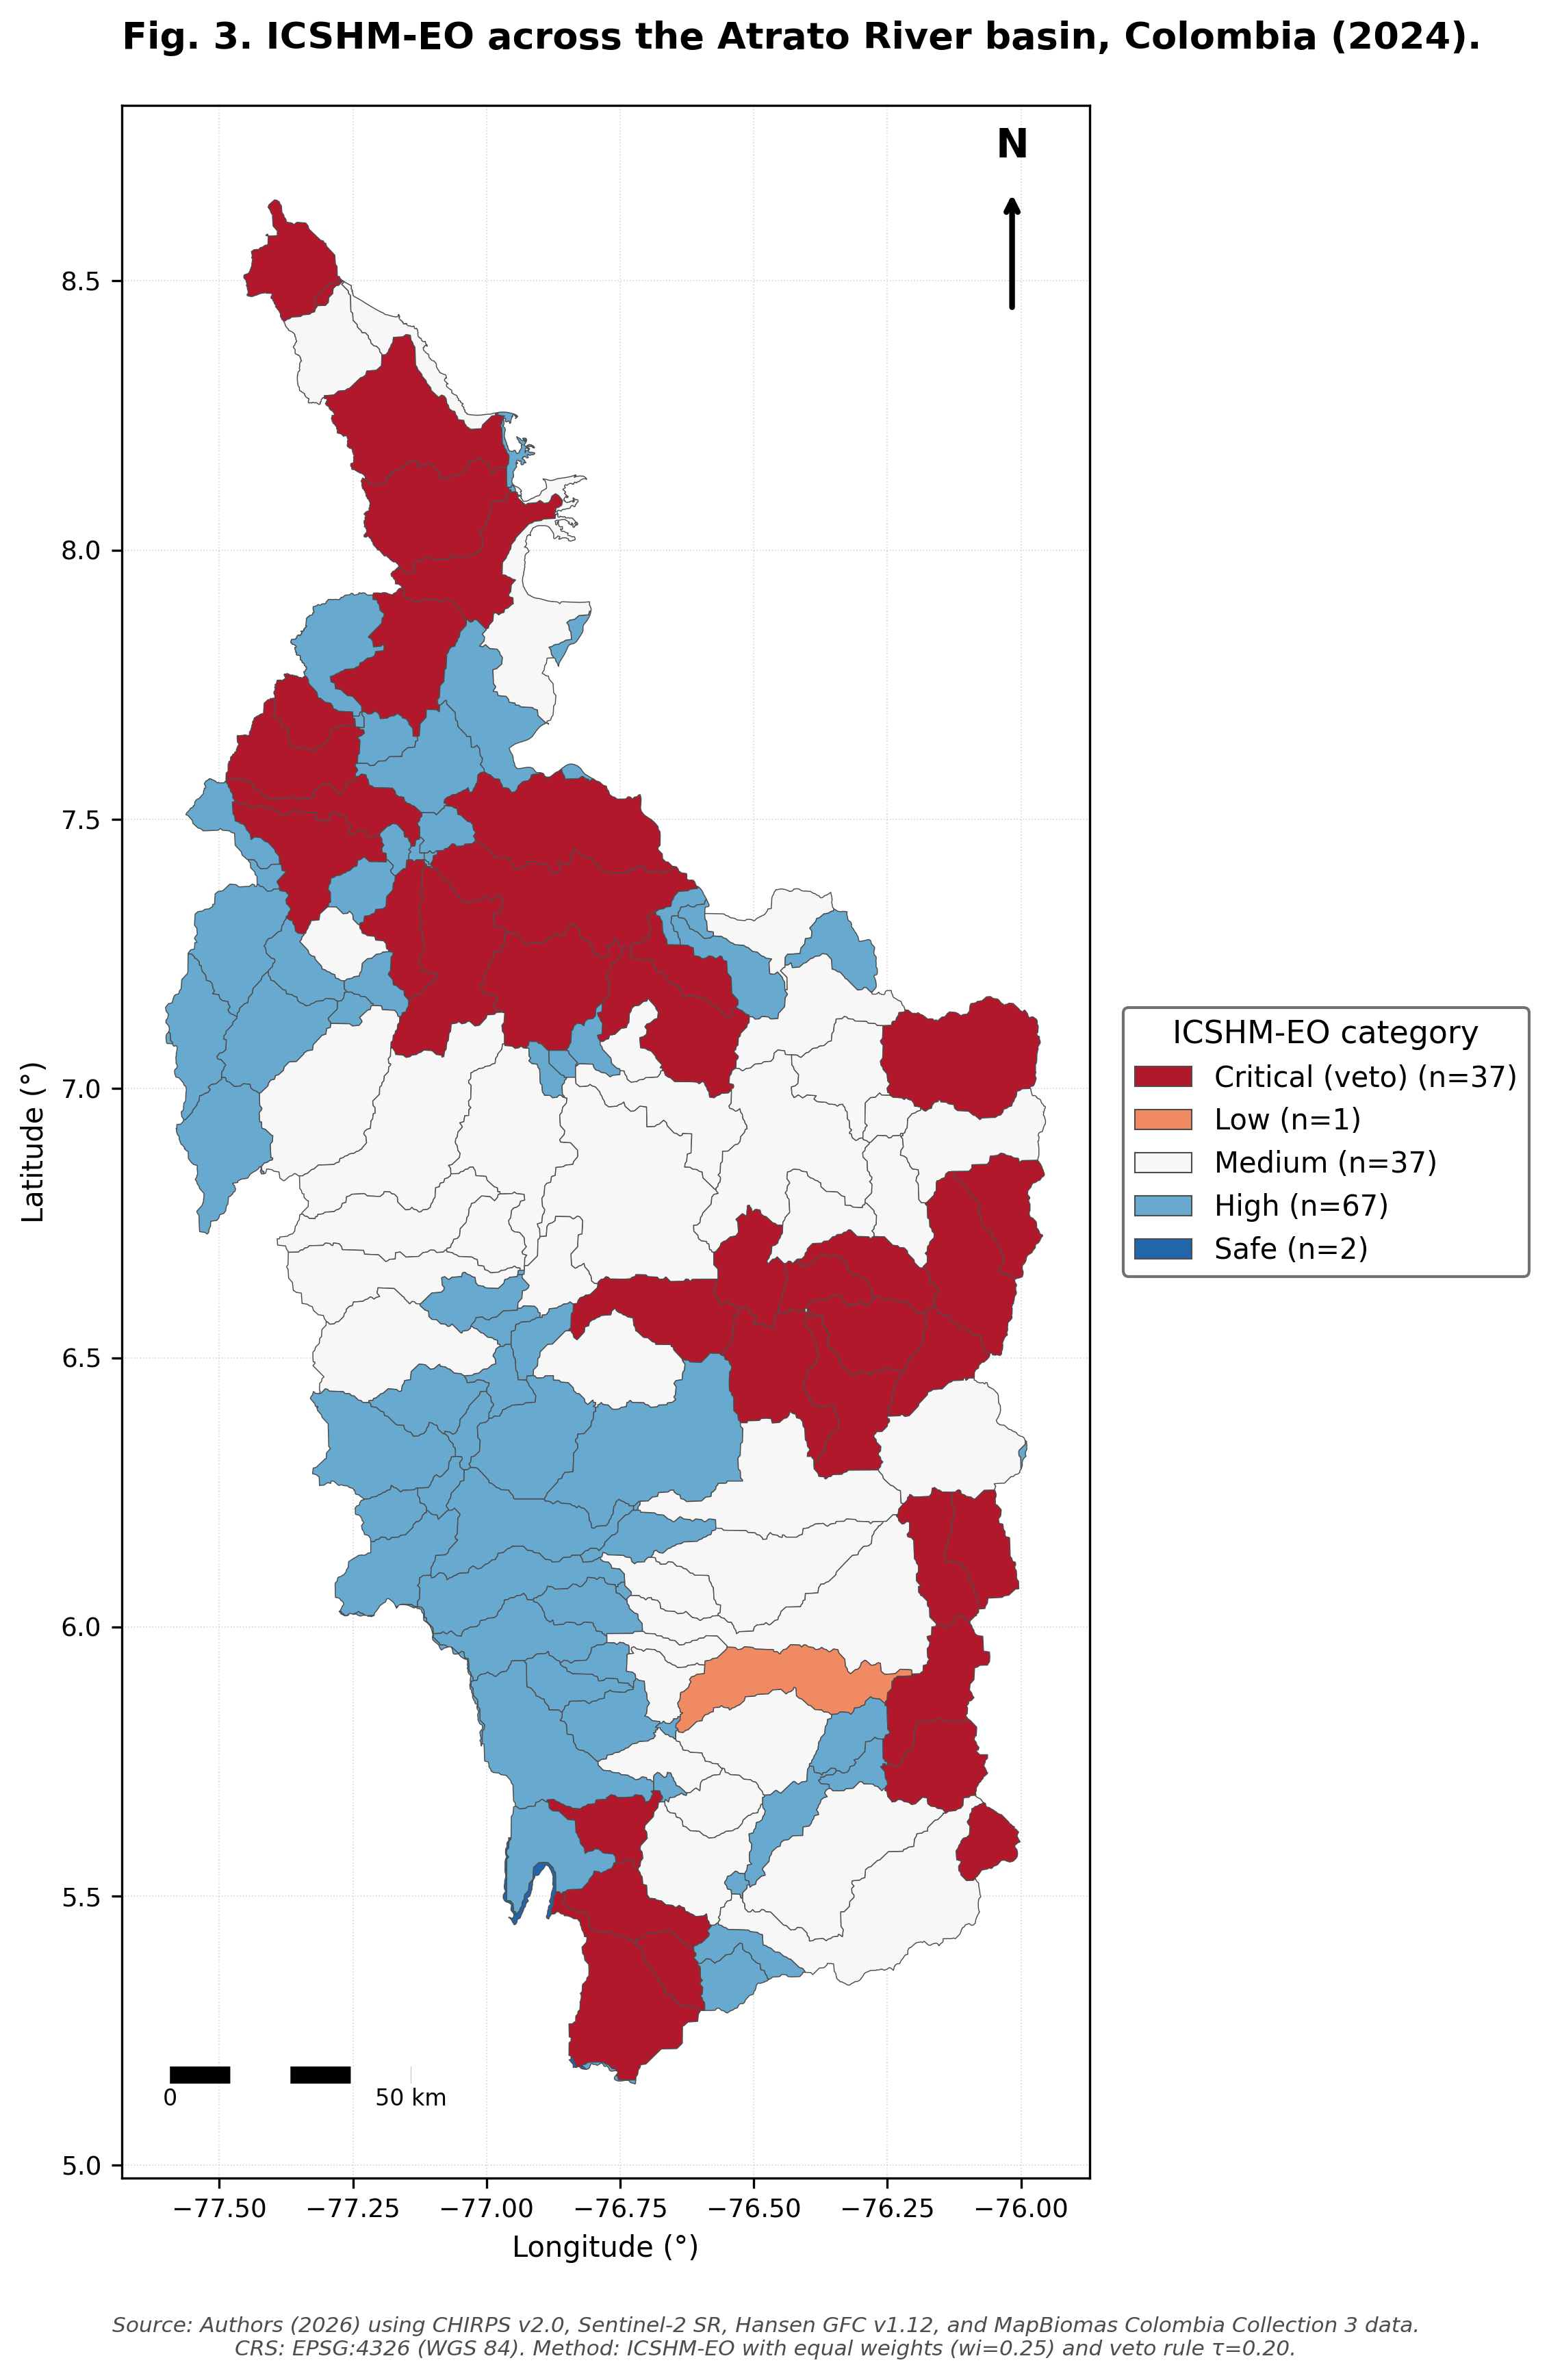


✅ Figura 3 corregida (leyenda afuera + inglés IEEE)


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Paleta ICSHM ColorBrewer RdBu
colores_icshm = {
    'Crítico (veto)': '#B2182B',
    'Crítico':         '#B2182B',
    'Bajo':            '#EF8A62',
    'Medio':           '#F7F7F7',
    'Alto':            '#67A9CF',
    'Seguro':          '#2166AC'
}

# Etiquetas en ingles para leyenda
labels_en = {
    'Crítico (veto)': 'Critical (veto)',
    'Bajo': 'Low',
    'Medio': 'Medium',
    'Alto': 'High',
    'Seguro': 'Safe'
}

gdf_valid['color'] = gdf_valid['categoria'].map(colores_icshm)

# Figura mas ancha para dejar espacio a la leyenda lateral
fig, ax = plt.subplots(1, 1, figsize=(13, 12), dpi=300)

gdf_valid.plot(
    ax=ax,
    color=gdf_valid['color'],
    edgecolor='#4D4D4D',
    linewidth=0.35
)

# Titulo formato IEEE en ingles
ax.set_title('Fig. 3. ICSHM-EO across the Atrato River basin, Colombia (2024).',
             fontsize=13, fontweight='bold', pad=20, loc='left')

ax.set_xlabel('Longitude (°)', fontsize=10)
ax.set_ylabel('Latitude (°)', fontsize=10)
ax.tick_params(labelsize=9)

# ---- ESCALA GRÁFICA ----
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

escala_km = 50
escala_grados = escala_km / 111
x_escala_start = xmin + (xmax - xmin) * 0.05
y_escala = ymin + (ymax - ymin) * 0.05

segmentos = 4
for i in range(segmentos):
    color = 'black' if i % 2 == 0 else 'white'
    x0 = x_escala_start + i * (escala_grados / segmentos)
    x1 = x_escala_start + (i + 1) * (escala_grados / segmentos)
    ax.plot([x0, x1], [y_escala, y_escala], color=color, linewidth=6,
            solid_capstyle='butt', zorder=10)
    ax.plot([x0, x1], [y_escala, y_escala], color='black', linewidth=6,
            solid_capstyle='butt', fillstyle='none', zorder=9)

ax.text(x_escala_start, y_escala - (ymax-ymin)*0.015, '0',
        fontsize=8, ha='center', zorder=11)
ax.text(x_escala_start + escala_grados, y_escala - (ymax-ymin)*0.015,
        f'{escala_km} km', fontsize=8, ha='center', zorder=11)

# ---- FLECHA DE NORTE ----
x_norte = xmin + (xmax - xmin) * 0.92
y_norte_base = ymin + (ymax - ymin) * 0.90
y_norte_punta = y_norte_base + (ymax - ymin) * 0.06

ax.annotate('', xy=(x_norte, y_norte_punta), xytext=(x_norte, y_norte_base),
            arrowprops=dict(arrowstyle='->', color='black', lw=2), zorder=10)
ax.text(x_norte, y_norte_punta + (ymax-ymin)*0.015, 'N',
        fontsize=14, fontweight='bold', ha='center', zorder=11)

# ---- LEYENDA AFUERA del mapa (lado derecho) ----
categorias_presentes = gdf_valid['categoria'].value_counts()
categorias_orden = ['Crítico (veto)', 'Bajo', 'Medio', 'Alto', 'Seguro']

patches = []
for cat in categorias_orden:
    if cat in categorias_presentes.index:
        n = categorias_presentes[cat]
        label = f'{labels_en[cat]} (n={n})'
        patches.append(mpatches.Patch(facecolor=colores_icshm[cat],
                                      label=label,
                                      edgecolor='#4D4D4D', linewidth=0.5))

ax.legend(handles=patches,
          loc='center left',
          bbox_to_anchor=(1.02, 0.5),
          fontsize=10, title='ICSHM-EO category',
          title_fontsize=11, frameon=True,
          facecolor='white', edgecolor='#4D4D4D')

# Grid sutil
ax.grid(True, linestyle=':', linewidth=0.4, color='#B0B0B0', alpha=0.5)
ax.set_axisbelow(True)

# Fonte formato IEEE en inglés
plt.figtext(0.5, 0.02,
            'Source: Authors (2026) using CHIRPS v2.0, Sentinel-2 SR, Hansen GFC v1.12, and MapBiomas Colombia Collection 3 data.\n'
            'CRS: EPSG:4326 (WGS 84). Method: ICSHM-EO with equal weights (wi=0.25) and veto rule τ=0.20.',
            ha='center', fontsize=7.5, style='italic', color='#4D4D4D')

plt.tight_layout(rect=[0, 0.045, 0.88, 0.98])

# Guardar
plt.savefig(carpeta + 'Fig3_ICSHM_EO_Atrato.png', dpi=600, bbox_inches='tight')
plt.savefig(carpeta + 'Fig3_ICSHM_EO_Atrato.pdf', bbox_inches='tight')
plt.show()

print("\n✅ Figura 3 corregida (leyenda afuera + inglés IEEE)")

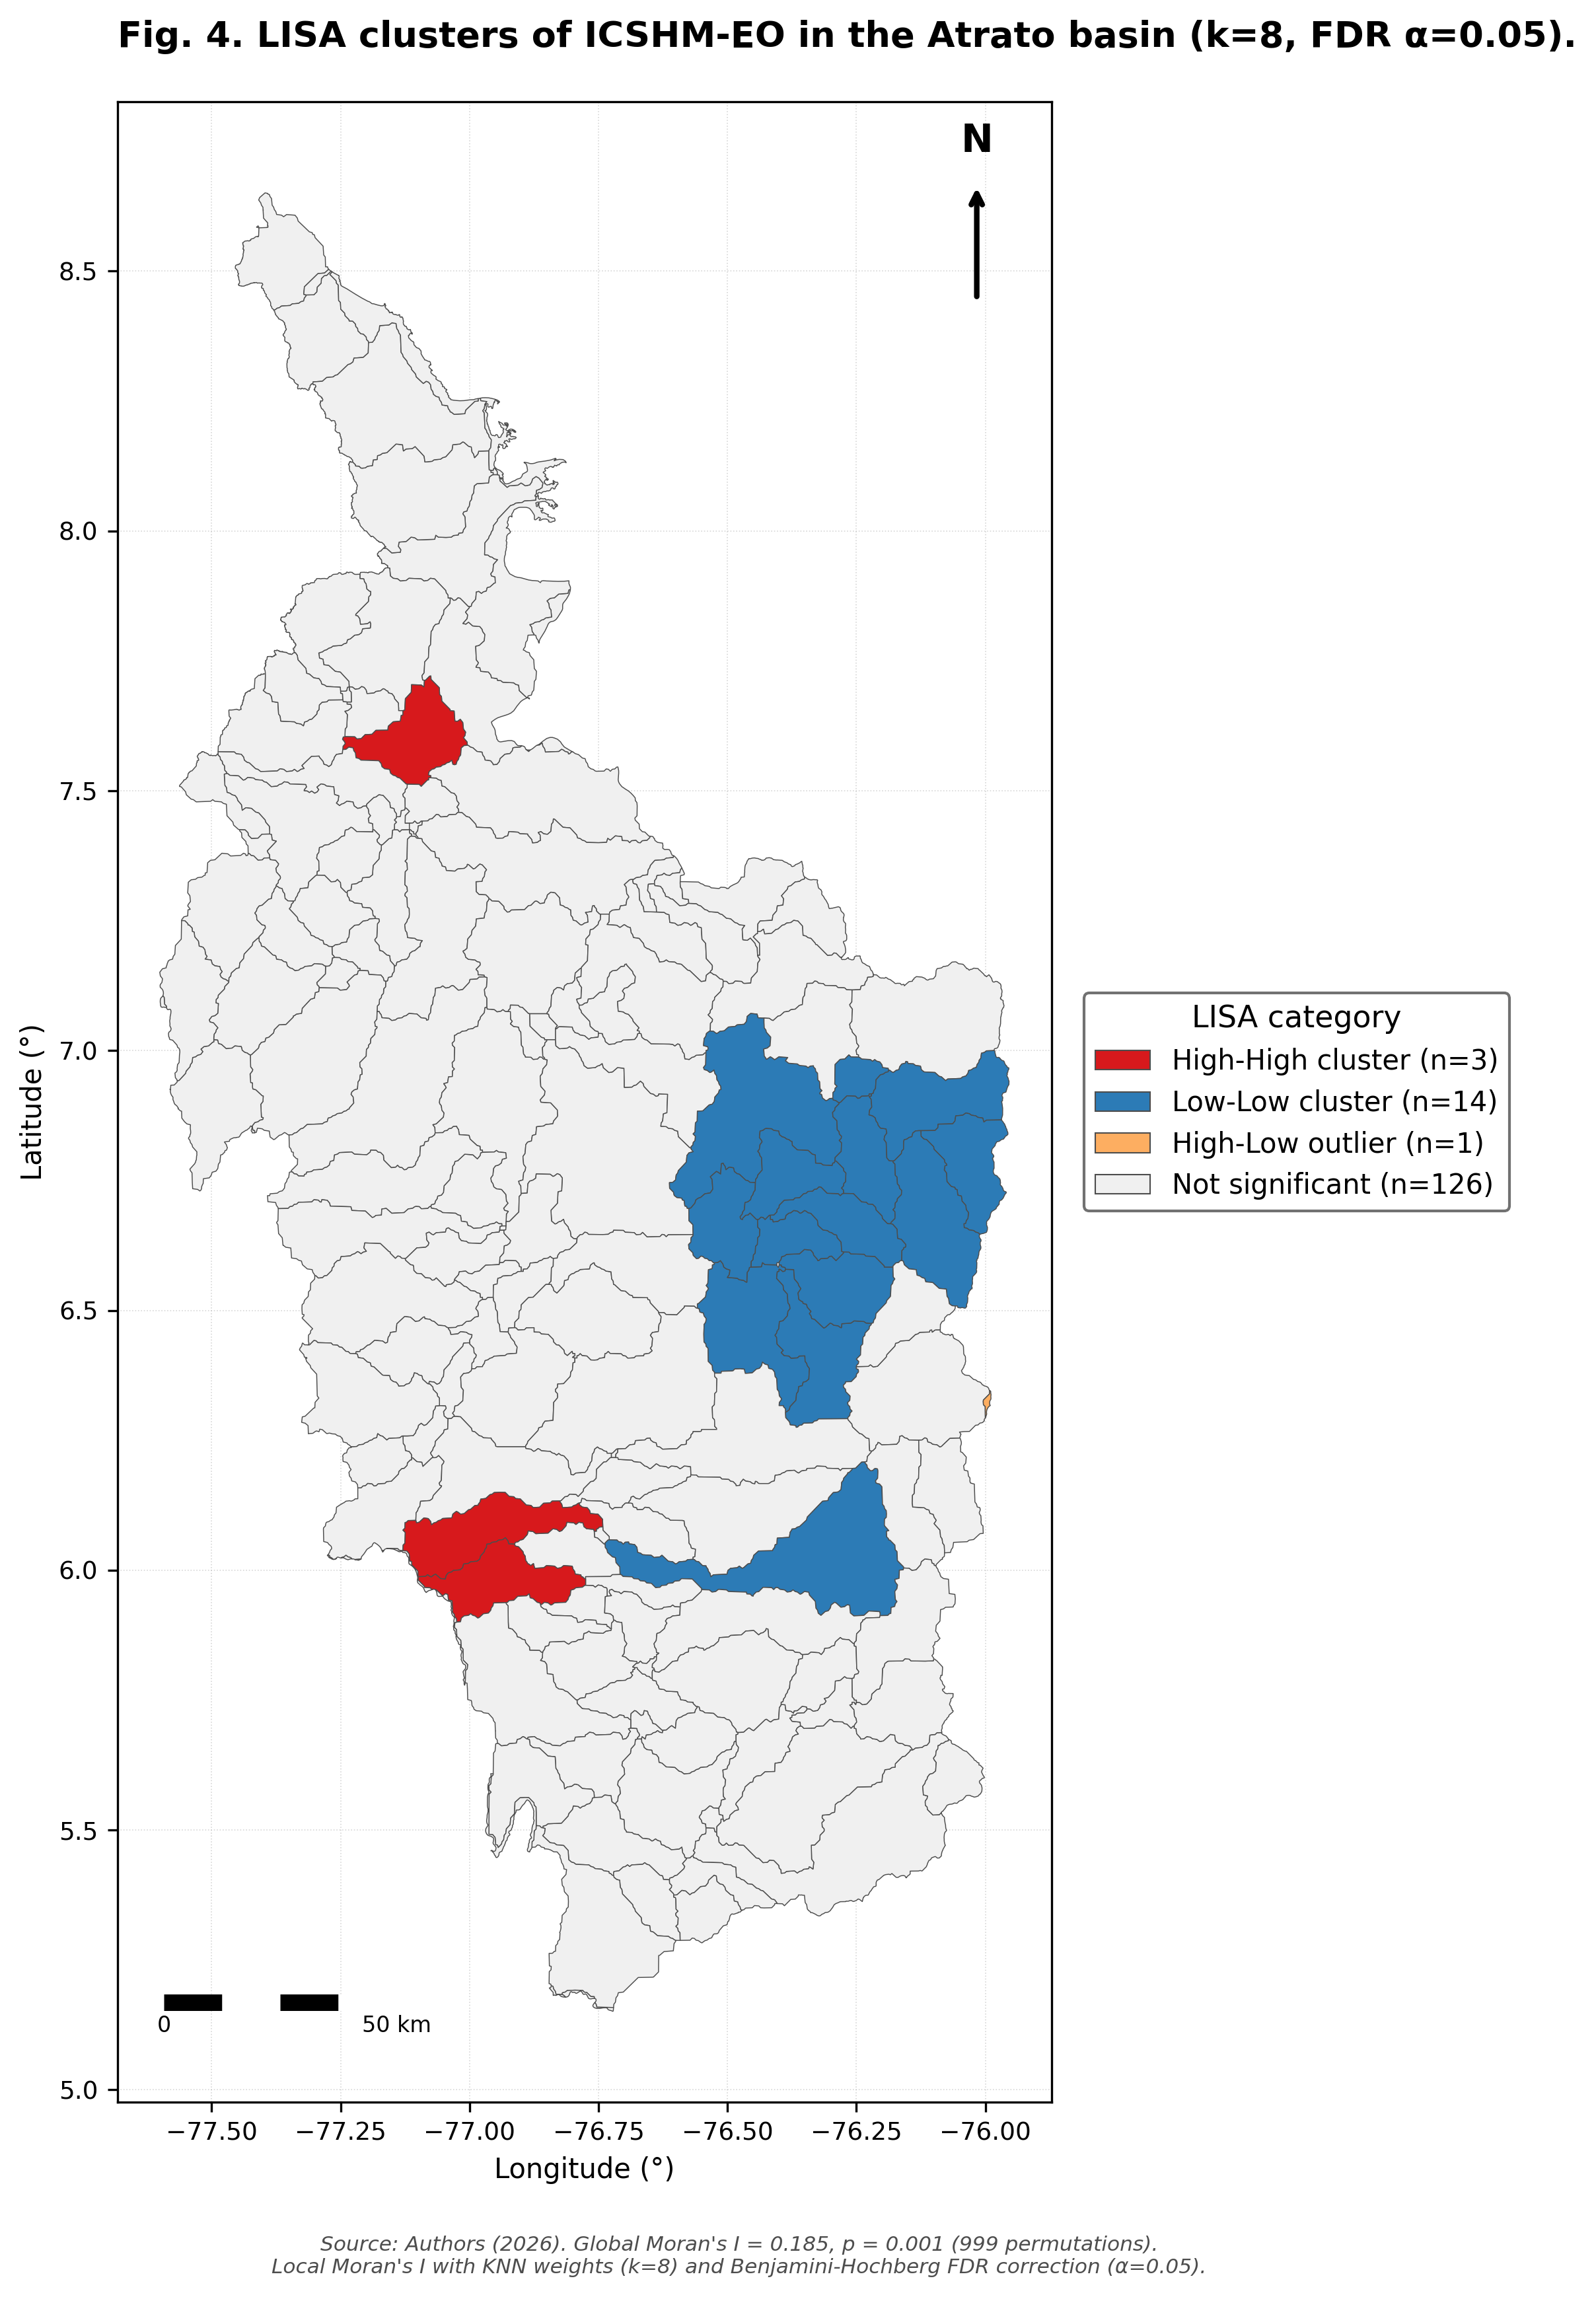

✅ Figura 4 LISA guardada


In [17]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Paleta LISA
colores_lisa = {
    'High-High': '#D7191C',
    'Low-Low':   '#2C7BB6',
    'High-Low':  '#FDAE61',
    'Low-High':  '#ABD9E9',
    'NS':        '#F0F0F0'
}

labels_lisa_en = {
    'High-High': 'High-High cluster',
    'Low-Low':   'Low-Low cluster',
    'High-Low':  'High-Low outlier',
    'Low-High':  'Low-High outlier',
    'NS':        'Not significant'
}

gdf_valid['color_lisa'] = gdf_valid['LISA_cat'].map(colores_lisa)

fig, ax = plt.subplots(1, 1, figsize=(13, 12), dpi=300)

gdf_valid.plot(
    ax=ax,
    color=gdf_valid['color_lisa'],
    edgecolor='#4D4D4D',
    linewidth=0.35
)

ax.set_title('Fig. 4. LISA clusters of ICSHM-EO in the Atrato basin (k=8, FDR α=0.05).',
             fontsize=13, fontweight='bold', pad=20, loc='left')
ax.set_xlabel('Longitude (°)', fontsize=10)
ax.set_ylabel('Latitude (°)', fontsize=10)
ax.tick_params(labelsize=9)

# Escala
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
escala_km = 50
escala_grados = escala_km / 111
x_escala_start = xmin + (xmax - xmin) * 0.05
y_escala = ymin + (ymax - ymin) * 0.05
for i in range(4):
    color = 'black' if i % 2 == 0 else 'white'
    x0 = x_escala_start + i * (escala_grados / 4)
    x1 = x_escala_start + (i + 1) * (escala_grados / 4)
    ax.plot([x0, x1], [y_escala, y_escala], color=color, linewidth=6,
            solid_capstyle='butt', zorder=10)
ax.text(x_escala_start, y_escala - (ymax-ymin)*0.015, '0',
        fontsize=8, ha='center', zorder=11)
ax.text(x_escala_start + escala_grados, y_escala - (ymax-ymin)*0.015,
        f'{escala_km} km', fontsize=8, ha='center', zorder=11)

# Norte
x_norte = xmin + (xmax - xmin) * 0.92
y_norte_base = ymin + (ymax - ymin) * 0.90
y_norte_punta = y_norte_base + (ymax - ymin) * 0.06
ax.annotate('', xy=(x_norte, y_norte_punta), xytext=(x_norte, y_norte_base),
            arrowprops=dict(arrowstyle='->', color='black', lw=2), zorder=10)
ax.text(x_norte, y_norte_punta + (ymax-ymin)*0.015, 'N',
        fontsize=14, fontweight='bold', ha='center', zorder=11)

# Leyenda con conteos
categorias_presentes = gdf_valid['LISA_cat'].value_counts()
orden_lisa = ['High-High', 'Low-Low', 'High-Low', 'Low-High', 'NS']

patches = []
for cat in orden_lisa:
    if cat in categorias_presentes.index:
        n = categorias_presentes[cat]
        patches.append(mpatches.Patch(facecolor=colores_lisa[cat],
                                      label=f'{labels_lisa_en[cat]} (n={n})',
                                      edgecolor='#4D4D4D', linewidth=0.5))

ax.legend(handles=patches, loc='center left', bbox_to_anchor=(1.02, 0.5),
          fontsize=10, title='LISA category', title_fontsize=11,
          frameon=True, facecolor='white', edgecolor='#4D4D4D')

ax.grid(True, linestyle=':', linewidth=0.4, color='#B0B0B0', alpha=0.5)
ax.set_axisbelow(True)

plt.figtext(0.5, 0.02,
            f"Source: Authors (2026). Global Moran's I = {moran.I:.3f}, p = {moran.p_sim:.3f} (999 permutations).\n"
            f"Local Moran's I with KNN weights (k=8) and Benjamini-Hochberg FDR correction (α=0.05).",
            ha='center', fontsize=7.5, style='italic', color='#4D4D4D')

plt.tight_layout(rect=[0, 0.045, 0.88, 0.98])

plt.savefig(carpeta + 'Fig4_LISA_Atrato.png', dpi=600, bbox_inches='tight')
plt.savefig(carpeta + 'Fig4_LISA_Atrato.pdf', bbox_inches='tight')
plt.show()

print("✅ Figura 4 LISA guardada")

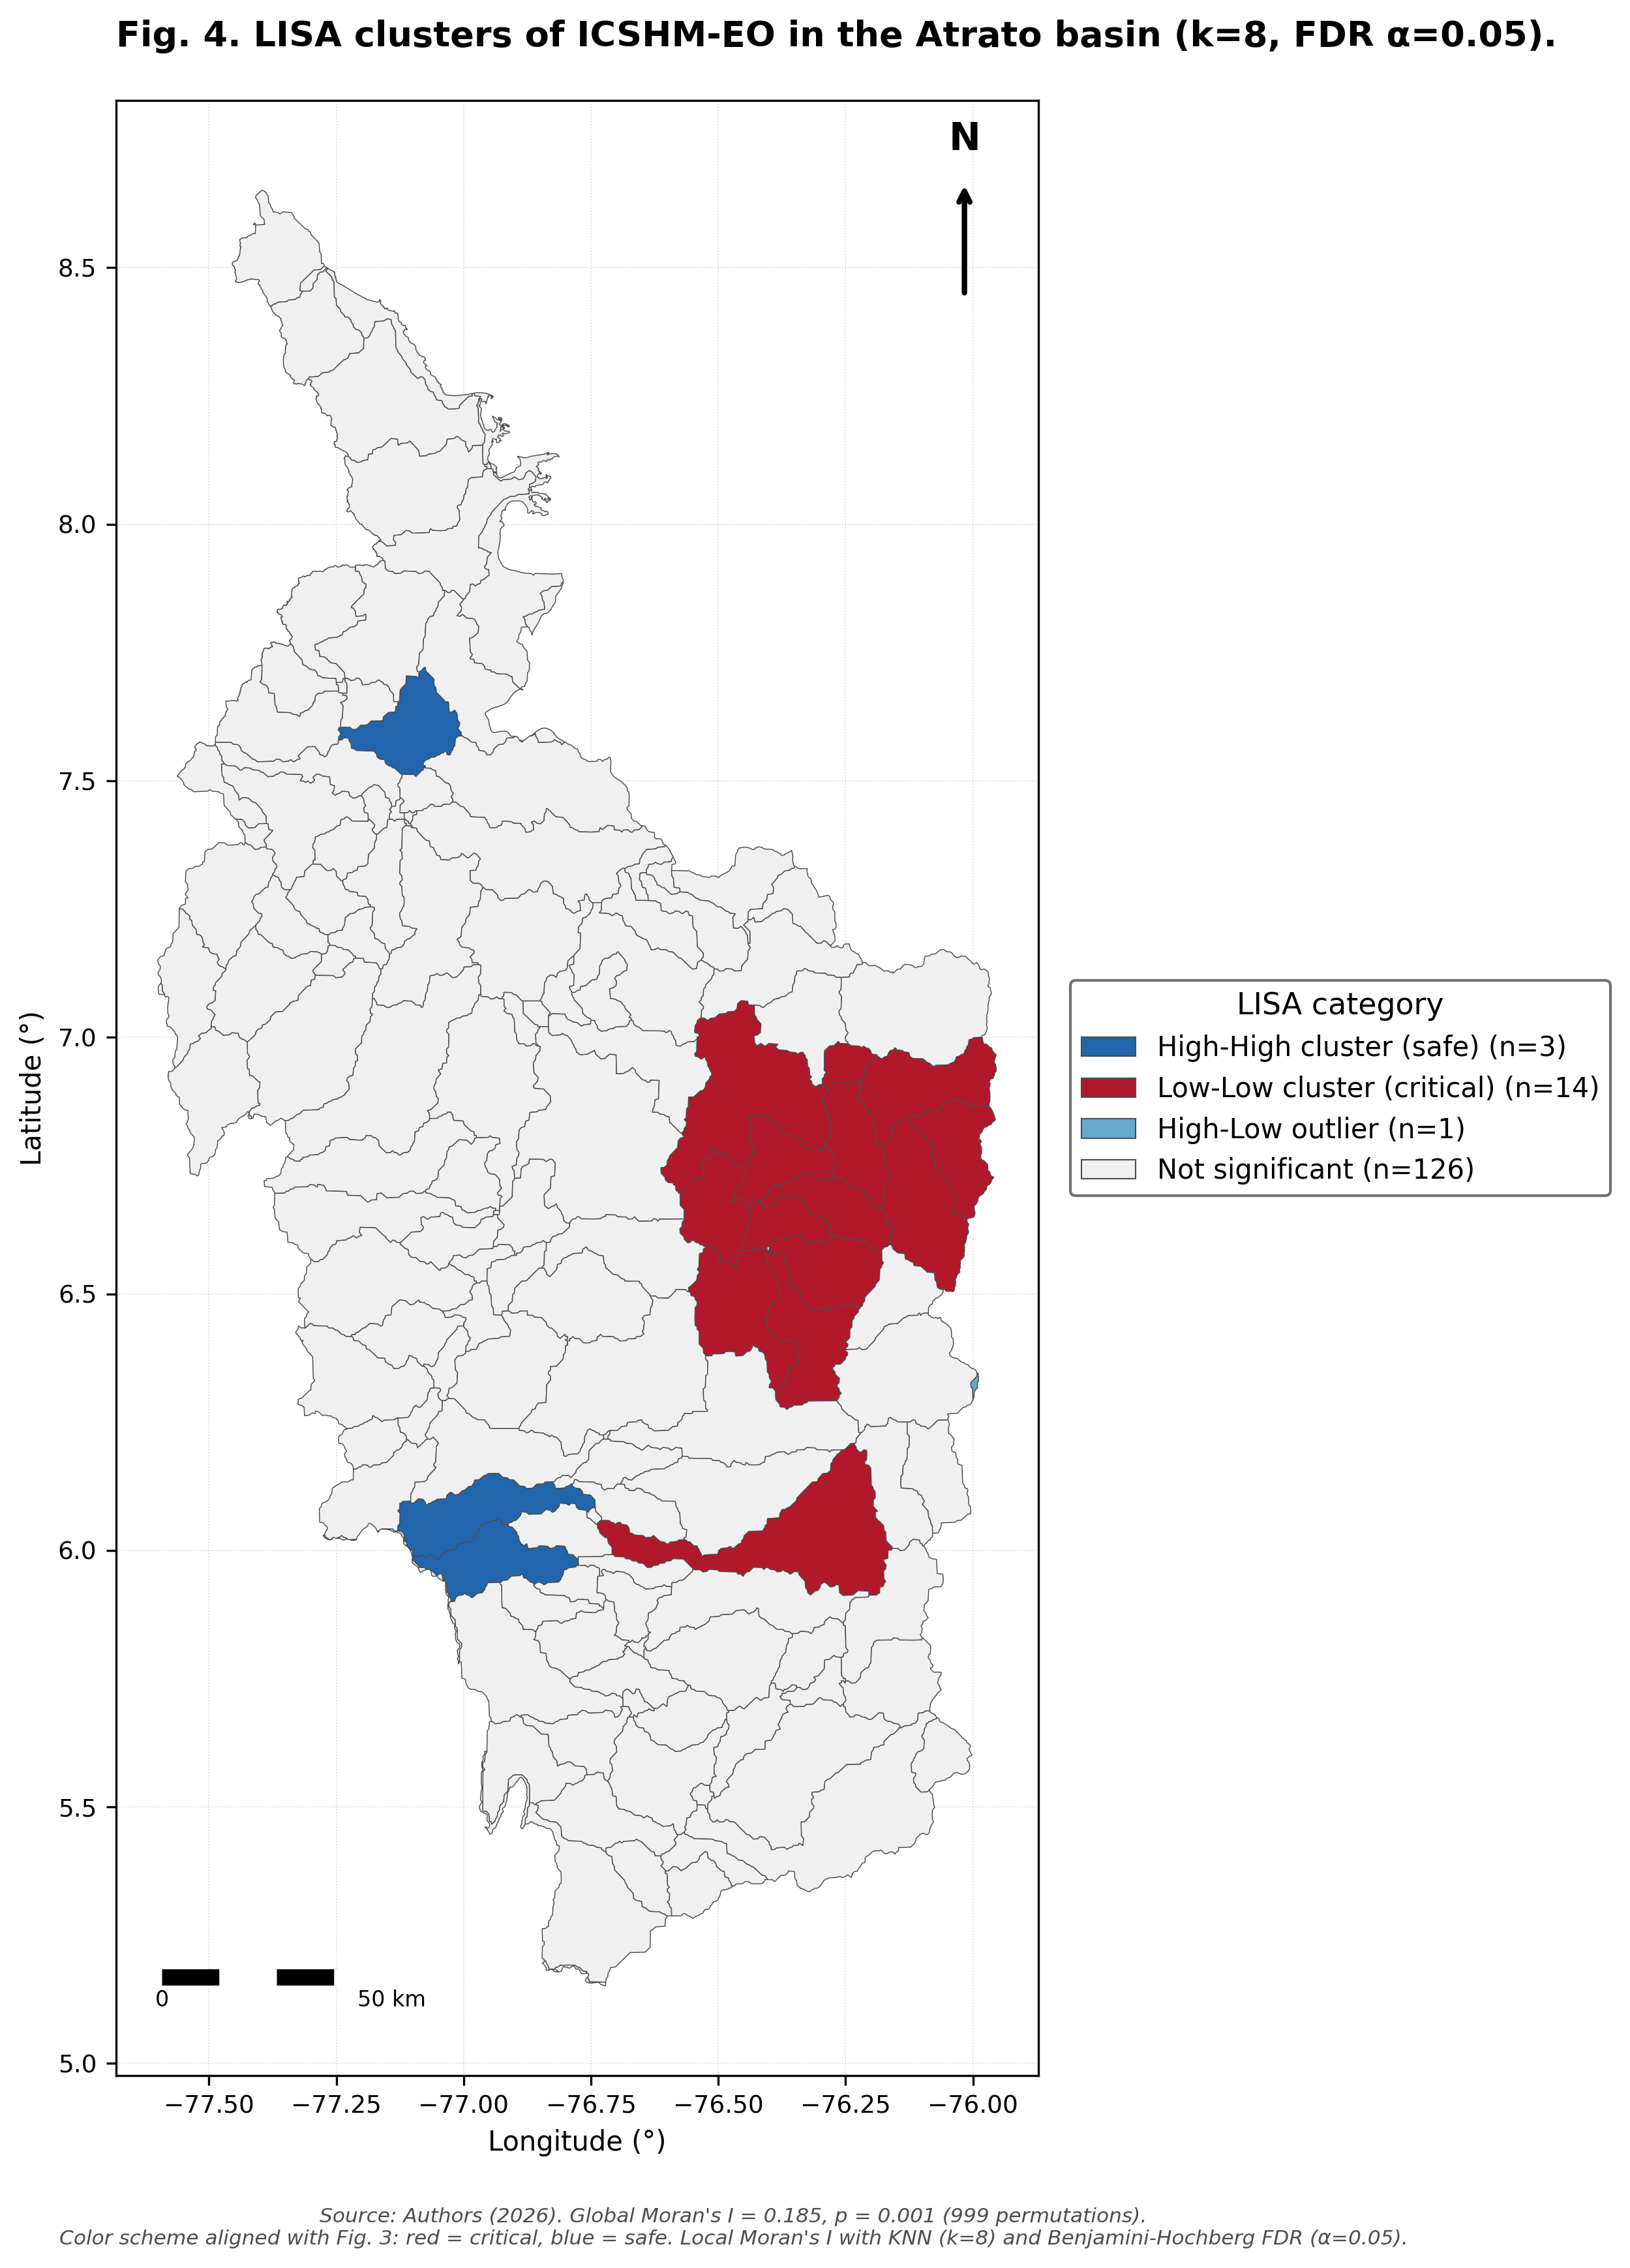

✅ Figura 4 corregida (paleta coherente con Fig 3)


In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Paleta LISA INVERTIDA para coherencia con Fig 3
# High-High = subcuencas seguras agrupadas → AZUL OSCURO
# Low-Low = subcuencas críticas agrupadas → ROJO OSCURO
colores_lisa = {
    'High-High': '#2166AC',   # azul oscuro = seguro
    'Low-Low':   '#B2182B',   # rojo oscuro = crítico
    'High-Low':  '#67A9CF',   # azul claro = outlier seguro entre críticos
    'Low-High':  '#EF8A62',   # naranja = outlier crítico entre seguros
    'NS':        '#F0F0F0'    # gris claro = no significativo
}

labels_lisa_en = {
    'High-High': 'High-High cluster (safe)',
    'Low-Low':   'Low-Low cluster (critical)',
    'High-Low':  'High-Low outlier',
    'Low-High':  'Low-High outlier',
    'NS':        'Not significant'
}

gdf_valid['color_lisa'] = gdf_valid['LISA_cat'].map(colores_lisa)

fig, ax = plt.subplots(1, 1, figsize=(13, 12), dpi=300)

gdf_valid.plot(
    ax=ax,
    color=gdf_valid['color_lisa'],
    edgecolor='#4D4D4D',
    linewidth=0.35
)

ax.set_title('Fig. 4. LISA clusters of ICSHM-EO in the Atrato basin (k=8, FDR α=0.05).',
             fontsize=13, fontweight='bold', pad=20, loc='left')
ax.set_xlabel('Longitude (°)', fontsize=10)
ax.set_ylabel('Latitude (°)', fontsize=10)
ax.tick_params(labelsize=9)

# Escala
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
escala_km = 50
escala_grados = escala_km / 111
x_escala_start = xmin + (xmax - xmin) * 0.05
y_escala = ymin + (ymax - ymin) * 0.05
for i in range(4):
    color = 'black' if i % 2 == 0 else 'white'
    x0 = x_escala_start + i * (escala_grados / 4)
    x1 = x_escala_start + (i + 1) * (escala_grados / 4)
    ax.plot([x0, x1], [y_escala, y_escala], color=color, linewidth=6,
            solid_capstyle='butt', zorder=10)
ax.text(x_escala_start, y_escala - (ymax-ymin)*0.015, '0',
        fontsize=8, ha='center', zorder=11)
ax.text(x_escala_start + escala_grados, y_escala - (ymax-ymin)*0.015,
        f'{escala_km} km', fontsize=8, ha='center', zorder=11)

# Norte
x_norte = xmin + (xmax - xmin) * 0.92
y_norte_base = ymin + (ymax - ymin) * 0.90
y_norte_punta = y_norte_base + (ymax - ymin) * 0.06
ax.annotate('', xy=(x_norte, y_norte_punta), xytext=(x_norte, y_norte_base),
            arrowprops=dict(arrowstyle='->', color='black', lw=2), zorder=10)
ax.text(x_norte, y_norte_punta + (ymax-ymin)*0.015, 'N',
        fontsize=14, fontweight='bold', ha='center', zorder=11)

# Leyenda
categorias_presentes = gdf_valid['LISA_cat'].value_counts()
orden_lisa = ['High-High', 'Low-Low', 'High-Low', 'Low-High', 'NS']

patches = []
for cat in orden_lisa:
    if cat in categorias_presentes.index:
        n = categorias_presentes[cat]
        patches.append(mpatches.Patch(facecolor=colores_lisa[cat],
                                      label=f'{labels_lisa_en[cat]} (n={n})',
                                      edgecolor='#4D4D4D', linewidth=0.5))

ax.legend(handles=patches, loc='center left', bbox_to_anchor=(1.02, 0.5),
          fontsize=10, title='LISA category', title_fontsize=11,
          frameon=True, facecolor='white', edgecolor='#4D4D4D')

ax.grid(True, linestyle=':', linewidth=0.4, color='#B0B0B0', alpha=0.5)
ax.set_axisbelow(True)

# Pie con nota explicativa de la coherencia cromatica
plt.figtext(0.5, 0.02,
            f"Source: Authors (2026). Global Moran's I = {moran.I:.3f}, p = {moran.p_sim:.3f} (999 permutations).\n"
            f"Color scheme aligned with Fig. 3: red = critical, blue = safe. Local Moran's I with KNN (k=8) and Benjamini-Hochberg FDR (α=0.05).",
            ha='center', fontsize=7.5, style='italic', color='#4D4D4D')

plt.tight_layout(rect=[0, 0.045, 0.88, 0.98])

plt.savefig(carpeta + 'Fig4_LISA_Atrato.png', dpi=600, bbox_inches='tight')
plt.savefig(carpeta + 'Fig4_LISA_Atrato.pdf', bbox_inches='tight')
plt.show()

print("✅ Figura 4 corregida (paleta coherente con Fig 3)")

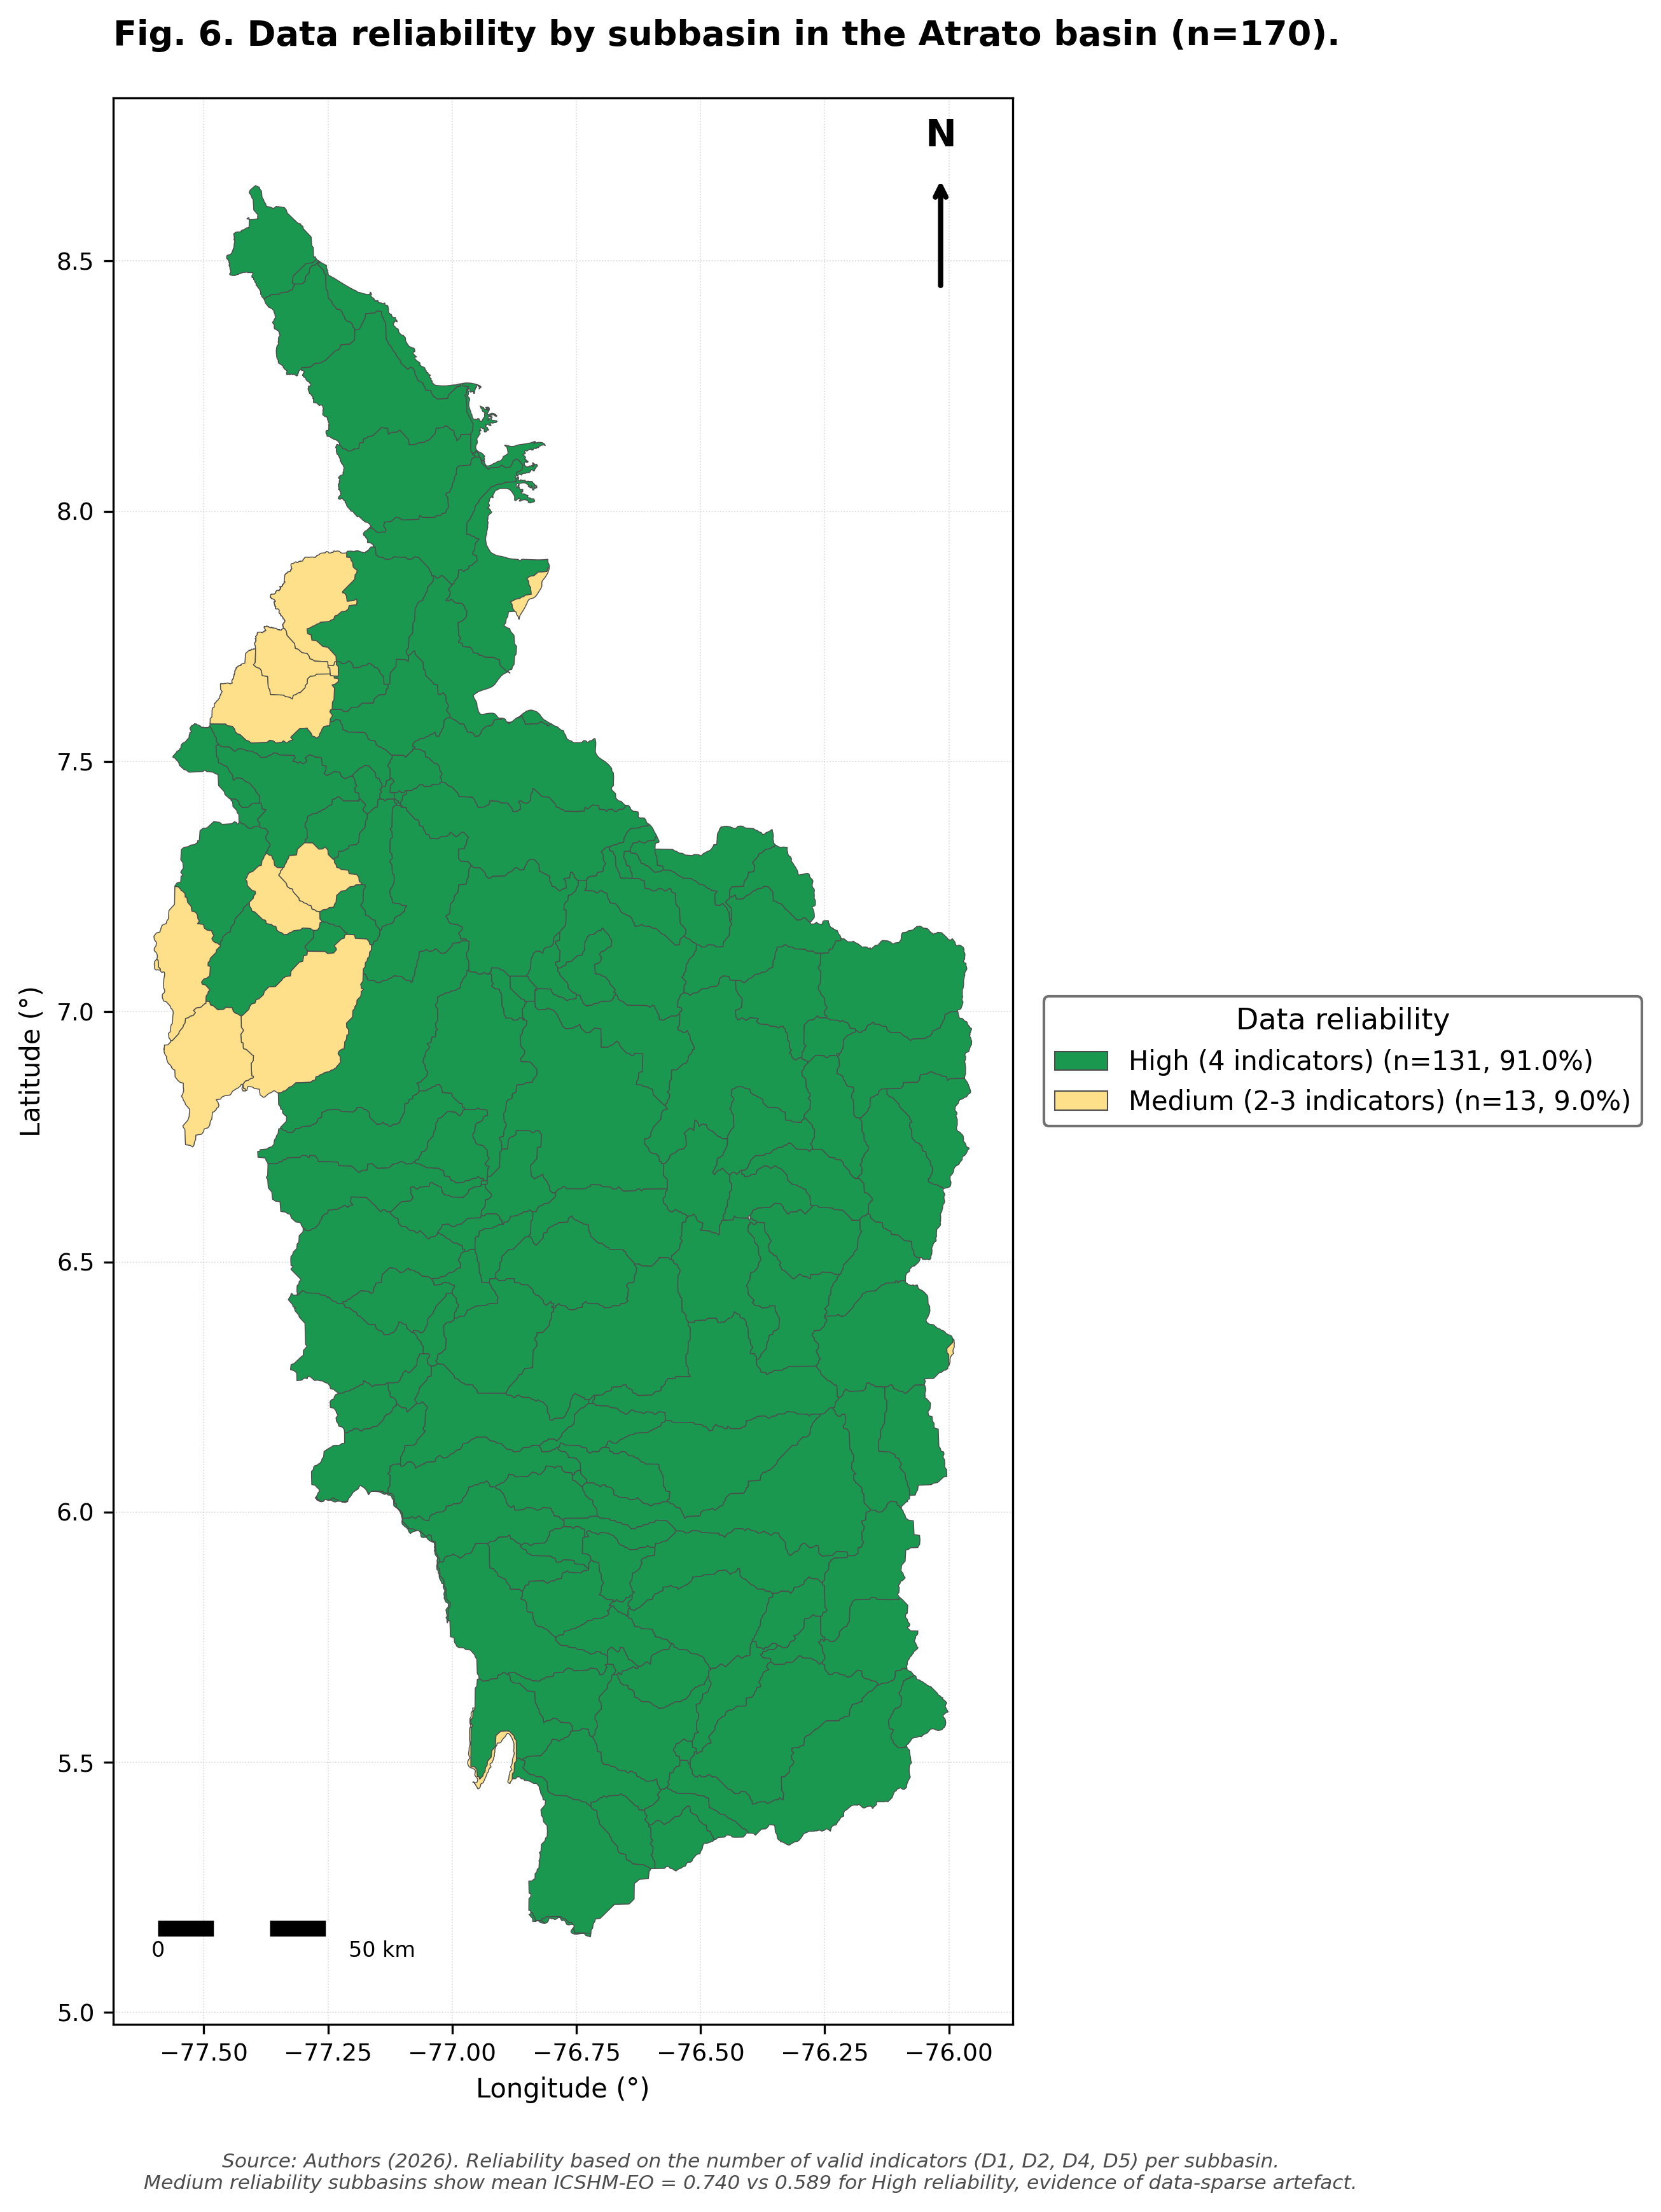

✅ Figura 6 guardada


In [19]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Merge para tener confiabilidad en el shapefile
gdf_conf = gdf.merge(df[['HYBAS_ID', 'n_indicadores_validos', 'confiabilidad']],
                     on='HYBAS_ID', how='left')

# Paleta semaforo
colores_conf = {
    'Verde (4 indicadores)':      '#1A9850',
    'Amarillo (2-3 indicadores)': '#FEE08B',
    'Rojo (0-1 indicador)':       '#D73027'
}

labels_conf_en = {
    'Verde (4 indicadores)':      'High (4 indicators)',
    'Amarillo (2-3 indicadores)': 'Medium (2-3 indicators)',
    'Rojo (0-1 indicador)':       'Low (0-1 indicator)'
}

gdf_conf['color'] = gdf_conf['confiabilidad'].map(colores_conf)
gdf_conf['color'] = gdf_conf['color'].fillna('#CCCCCC')

fig, ax = plt.subplots(1, 1, figsize=(13, 12), dpi=300)

gdf_conf.plot(
    ax=ax,
    color=gdf_conf['color'],
    edgecolor='#4D4D4D',
    linewidth=0.35
)

ax.set_title('Fig. 6. Data reliability by subbasin in the Atrato basin (n=170).',
             fontsize=13, fontweight='bold', pad=20, loc='left')
ax.set_xlabel('Longitude (°)', fontsize=10)
ax.set_ylabel('Latitude (°)', fontsize=10)
ax.tick_params(labelsize=9)

# Escala
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
escala_km = 50
escala_grados = escala_km / 111
x_escala_start = xmin + (xmax - xmin) * 0.05
y_escala = ymin + (ymax - ymin) * 0.05
for i in range(4):
    color = 'black' if i % 2 == 0 else 'white'
    x0 = x_escala_start + i * (escala_grados / 4)
    x1 = x_escala_start + (i + 1) * (escala_grados / 4)
    ax.plot([x0, x1], [y_escala, y_escala], color=color, linewidth=6,
            solid_capstyle='butt', zorder=10)
ax.text(x_escala_start, y_escala - (ymax-ymin)*0.015, '0',
        fontsize=8, ha='center', zorder=11)
ax.text(x_escala_start + escala_grados, y_escala - (ymax-ymin)*0.015,
        f'{escala_km} km', fontsize=8, ha='center', zorder=11)

# Norte
x_norte = xmin + (xmax - xmin) * 0.92
y_norte_base = ymin + (ymax - ymin) * 0.90
y_norte_punta = y_norte_base + (ymax - ymin) * 0.06
ax.annotate('', xy=(x_norte, y_norte_punta), xytext=(x_norte, y_norte_base),
            arrowprops=dict(arrowstyle='->', color='black', lw=2), zorder=10)
ax.text(x_norte, y_norte_punta + (ymax-ymin)*0.015, 'N',
        fontsize=14, fontweight='bold', ha='center', zorder=11)

# Leyenda
categorias_presentes = gdf_conf['confiabilidad'].value_counts()
orden_conf = ['Verde (4 indicadores)', 'Amarillo (2-3 indicadores)', 'Rojo (0-1 indicador)']

patches = []
for cat in orden_conf:
    if cat in categorias_presentes.index:
        n = categorias_presentes[cat]
        pct = 100 * n / len(gdf_conf)
        patches.append(mpatches.Patch(facecolor=colores_conf[cat],
                                      label=f'{labels_conf_en[cat]} (n={n}, {pct:.1f}%)',
                                      edgecolor='#4D4D4D', linewidth=0.5))

ax.legend(handles=patches, loc='center left', bbox_to_anchor=(1.02, 0.5),
          fontsize=10, title='Data reliability', title_fontsize=11,
          frameon=True, facecolor='white', edgecolor='#4D4D4D')

ax.grid(True, linestyle=':', linewidth=0.4, color='#B0B0B0', alpha=0.5)
ax.set_axisbelow(True)

plt.figtext(0.5, 0.02,
            f"Source: Authors (2026). Reliability based on the number of valid indicators (D1, D2, D4, D5) per subbasin.\n"
            f"Medium reliability subbasins show mean ICSHM-EO = 0.740 vs 0.589 for High reliability, evidence of data-sparse artefact.",
            ha='center', fontsize=7.5, style='italic', color='#4D4D4D')

plt.tight_layout(rect=[0, 0.045, 0.88, 0.98])

plt.savefig(carpeta + 'Fig6_Confiabilidad_Atrato.png', dpi=600, bbox_inches='tight')
plt.savefig(carpeta + 'Fig6_Confiabilidad_Atrato.pdf', bbox_inches='tight')
plt.show()

print("✅ Figura 6 guardada")

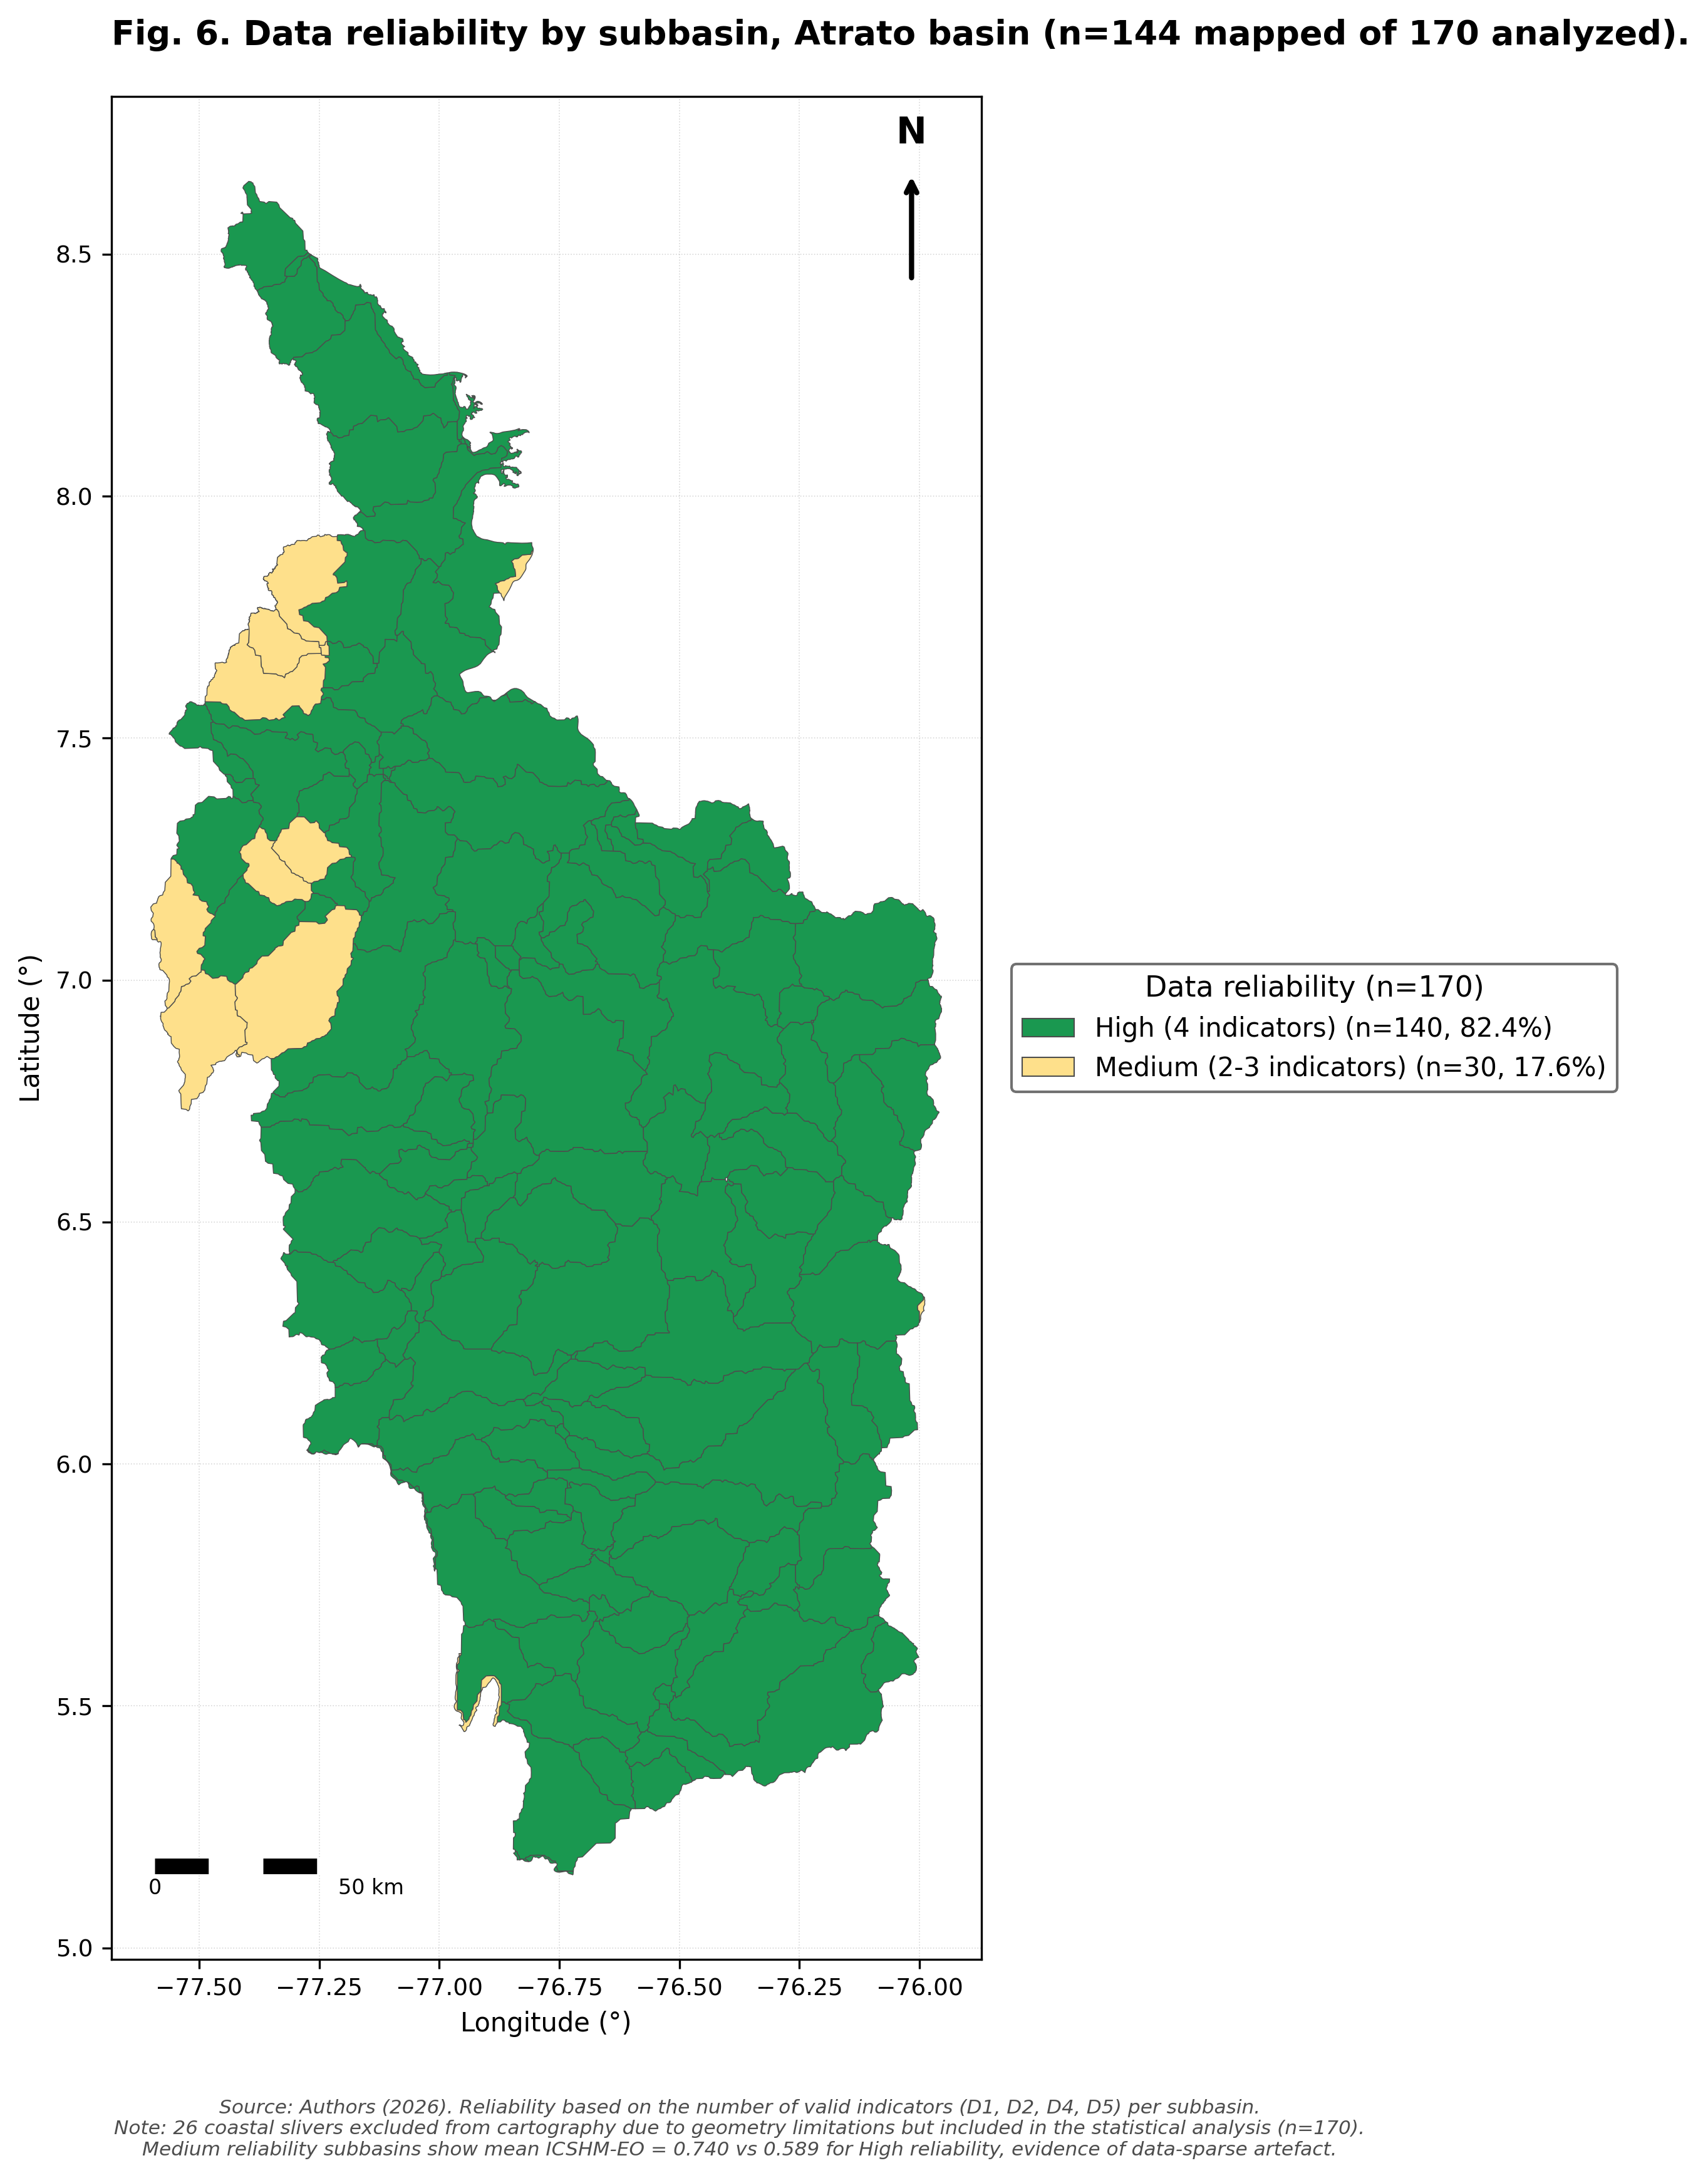

✅ Figura 6 corregida (n=170 global)


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Merge para tener confiabilidad en el shapefile
gdf_conf = gdf.merge(df[['HYBAS_ID', 'n_indicadores_validos', 'confiabilidad']],
                     on='HYBAS_ID', how='left')

colores_conf = {
    'Verde (4 indicadores)':      '#1A9850',
    'Amarillo (2-3 indicadores)': '#FEE08B',
    'Rojo (0-1 indicador)':       '#D73027'
}

gdf_conf['color'] = gdf_conf['confiabilidad'].map(colores_conf)
gdf_conf['color'] = gdf_conf['color'].fillna('#CCCCCC')

fig, ax = plt.subplots(1, 1, figsize=(13, 12), dpi=300)

gdf_conf.plot(
    ax=ax,
    color=gdf_conf['color'],
    edgecolor='#4D4D4D',
    linewidth=0.35
)

ax.set_title('Fig. 6. Data reliability by subbasin, Atrato basin (n=144 mapped of 170 analyzed).',
             fontsize=13, fontweight='bold', pad=20, loc='left')
ax.set_xlabel('Longitude (°)', fontsize=10)
ax.set_ylabel('Latitude (°)', fontsize=10)
ax.tick_params(labelsize=9)

# Escala
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
escala_km = 50
escala_grados = escala_km / 111
x_escala_start = xmin + (xmax - xmin) * 0.05
y_escala = ymin + (ymax - ymin) * 0.05
for i in range(4):
    color = 'black' if i % 2 == 0 else 'white'
    x0 = x_escala_start + i * (escala_grados / 4)
    x1 = x_escala_start + (i + 1) * (escala_grados / 4)
    ax.plot([x0, x1], [y_escala, y_escala], color=color, linewidth=6,
            solid_capstyle='butt', zorder=10)
ax.text(x_escala_start, y_escala - (ymax-ymin)*0.015, '0',
        fontsize=8, ha='center', zorder=11)
ax.text(x_escala_start + escala_grados, y_escala - (ymax-ymin)*0.015,
        f'{escala_km} km', fontsize=8, ha='center', zorder=11)

# Norte
x_norte = xmin + (xmax - xmin) * 0.92
y_norte_base = ymin + (ymax - ymin) * 0.90
y_norte_punta = y_norte_base + (ymax - ymin) * 0.06
ax.annotate('', xy=(x_norte, y_norte_punta), xytext=(x_norte, y_norte_base),
            arrowprops=dict(arrowstyle='->', color='black', lw=2), zorder=10)
ax.text(x_norte, y_norte_punta + (ymax-ymin)*0.015, 'N',
        fontsize=14, fontweight='bold', ha='center', zorder=11)

# CONTEOS GLOBALES SOBRE 170 (base analitica completa)
n_verde_total = (df['confiabilidad'] == 'Verde (4 indicadores)').sum()
n_amarillo_total = (df['confiabilidad'] == 'Amarillo (2-3 indicadores)').sum()

patches = [
    mpatches.Patch(facecolor=colores_conf['Verde (4 indicadores)'],
                   label=f'High (4 indicators) (n={n_verde_total}, {100*n_verde_total/170:.1f}%)',
                   edgecolor='#4D4D4D', linewidth=0.5),
    mpatches.Patch(facecolor=colores_conf['Amarillo (2-3 indicadores)'],
                   label=f'Medium (2-3 indicators) (n={n_amarillo_total}, {100*n_amarillo_total/170:.1f}%)',
                   edgecolor='#4D4D4D', linewidth=0.5)
]

ax.legend(handles=patches, loc='center left', bbox_to_anchor=(1.02, 0.5),
          fontsize=10, title='Data reliability (n=170)', title_fontsize=11,
          frameon=True, facecolor='white', edgecolor='#4D4D4D')

ax.grid(True, linestyle=':', linewidth=0.4, color='#B0B0B0', alpha=0.5)
ax.set_axisbelow(True)

plt.figtext(0.5, 0.02,
            f"Source: Authors (2026). Reliability based on the number of valid indicators (D1, D2, D4, D5) per subbasin.\n"
            f"Note: 26 coastal slivers excluded from cartography due to geometry limitations but included in the statistical analysis (n=170).\n"
            f"Medium reliability subbasins show mean ICSHM-EO = 0.740 vs 0.589 for High reliability, evidence of data-sparse artefact.",
            ha='center', fontsize=7.5, style='italic', color='#4D4D4D')

plt.tight_layout(rect=[0, 0.06, 0.88, 0.98])

plt.savefig(carpeta + 'Fig6_Confiabilidad_Atrato.png', dpi=600, bbox_inches='tight')
plt.savefig(carpeta + 'Fig6_Confiabilidad_Atrato.pdf', bbox_inches='tight')
plt.show()

print("✅ Figura 6 corregida (n=170 global)")